### Computing EPR for different seeds of AdEx MF

### Import packages and functions

Available keys in .mat file: ['matrix']
Data shape: (68, 68)
{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Fri Jan 24 14:45:59 2025', '__version__': '1.0', '__globals__': [], 'matrix': array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  2.75371005, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  2.75371005,  0.        , ...,  0.        ,
         0.        ,  2.61450098],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , 10.25416409],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  8.96293808],
       [ 0.        ,  0.        ,  2.61450098, ..., 10.25416409,
         8.96293808,  0.        ]])}
Time points: 68, Nodes: 68

Model fit correlation: 0.2922
Model fit distance: 0.9358
Number of iterations: 12

Fitted Jacobian eigenvalues (max real part): -2.3009

Differential e

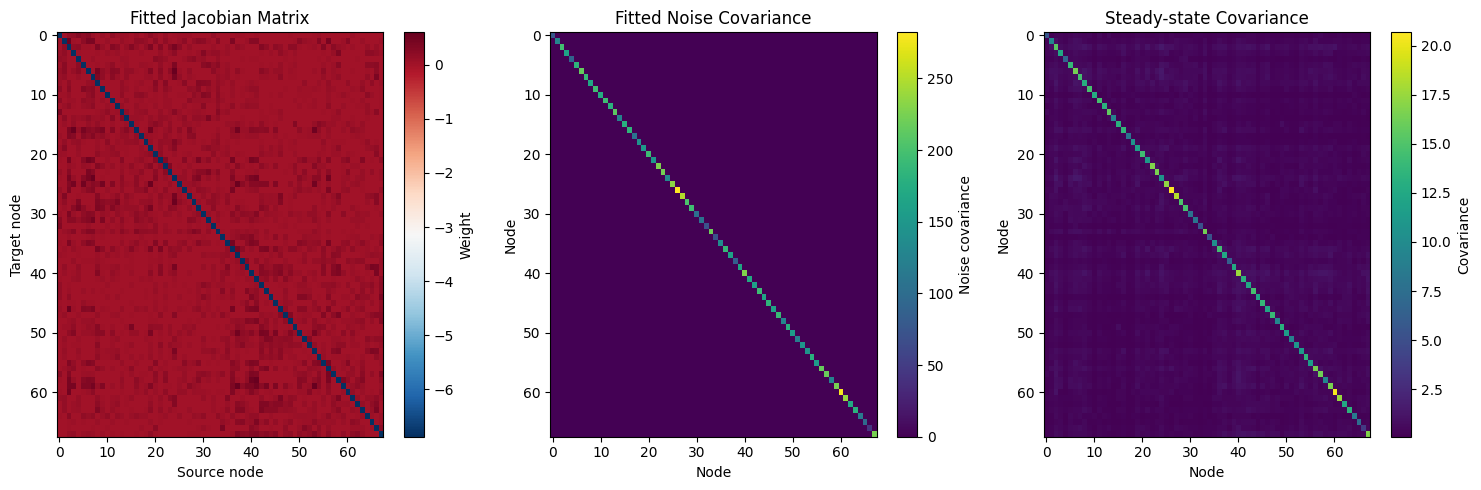

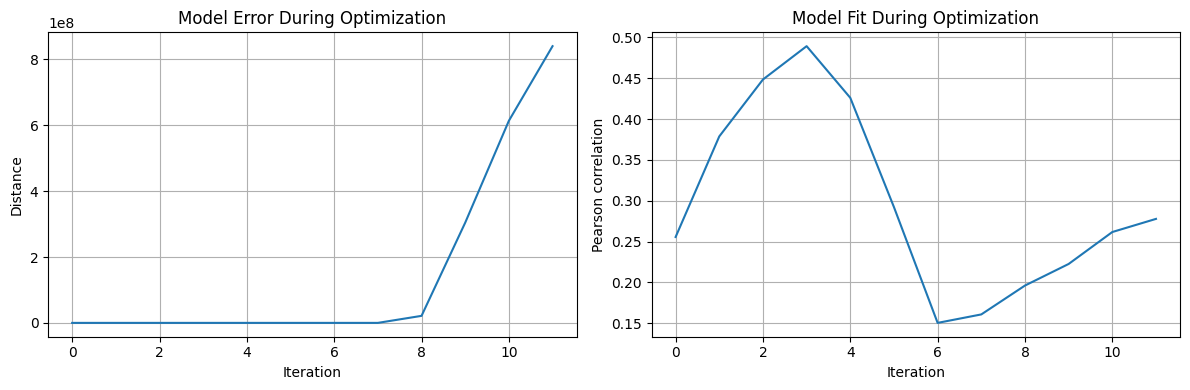

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import pandas as pd
import seaborn as sb 
from scipy import stats
from utils import *

### Set up repositories and saving paths

In [3]:
# Set up path and parameters to retrieve data
data_path = "D:\\Cogmaster\\M2\\stage\\data\\all_subfolders_b_es_speed_4"
reduced_b_query = "b_e_1.0"
baseline_b_query = "b_e_5.0"
bold_filename = "bold.npy"
temporal_avg_filename = "temporal_average.npy"

# Set up path and parameters to save results
res_dir = 'D:\\Cogmaster\\M2\\stage\\results\\MF_AdEx_different_b_vals' # results
presentation_figs_dir = 'D:\\Cogmaster\\M2\\stage\\figs\\MF_AdEx_different_b_vals'
os.makedirs(presentation_figs_dir, exist_ok=True)
graph_format = 'pdf' # graph formatting

# Possible situations to analyze
situations = ['simulated_adex_BOLD', 'simulated_adex_FR']
# Extract the b value from the query strings (e.g. "b_e_5" -> "5"), used for graph labels
baseline_b_value = baseline_b_query.split("_")[-1]
reduced_b_value = reduced_b_query.split("_")[-1]
# Number of conditions (baseline simulation emulates control condition, reduced b emulates psilocybin or schizophrenia condition)
conds = [f'b = {baseline_b_value}', f'b = {reduced_b_value}']
n_cond = len(conds) 
# Number of subjects (seeds)
n_sub = 15 
# Number of lags (0 and 1) for Q matrices
n_tau = 2 
# Cut transient 
cut_transient_fr = 20_000
cut_transient_bold = 10

### Set global parameters

In [4]:
# Number of conditions (baseline simulation emulates control condition, reduced b emulates psilocybin or schizophrenia condition)
conds = [f'b = {baseline_b_value}', f'b = {reduced_b_value}']
n_cond = len(conds) 

# Number of subjects (seeds)
n_sub = 15 
# Number of lags (0 and 1) for Q matrices
n_tau = 2 
# Cut transient 
cut_transient_fr = 20_000
cut_transient_bold = 10

### Loading the time-series data

In [5]:
# Get all the elements (normally only folders) in the data path 
list_directory = os.listdir(data_path)
reduced_b_folders = [k for k in list_directory if baseline_b_query in k]
baseline_b_folders = [k for k in list_directory if reduced_b_query in k]
assert len(reduced_b_folders) == len(baseline_b_folders), "Expected same number of folders for reduced and baseline b conditions"

nb_seeds = len(reduced_b_folders)
print(f"Found {nb_seeds} seeds for each condition")

# Load arbitrary file to get time points and regions
bold_temp = np.load(os.path.join(data_path, list_directory[0], bold_filename))
temporal_average_temp = np.load(os.path.join(data_path, list_directory[0], temporal_avg_filename))
n_timepoints_bold, n_regions = bold_temp.shape[0], bold_temp.shape[-1]
n_timepoints_temporal_avg = temporal_average_temp.shape[0]
print(f"BOLD time points: {n_timepoints_bold}. Firing rate time points: {n_timepoints_temporal_avg}. Regions: {n_regions}")

# Set up parameters important for data processing
# Check that number of seeds is the same as the user-defined number of subjects
assert nb_seeds == n_sub, f"Expected {n_sub} seeds but found {nb_seeds} in the data folders"

# Initialize array to hold all BOLD data
bold_data = np.zeros((nb_seeds, n_timepoints_bold-cut_transient_bold, n_regions, n_cond))
temporal_avg_data = np.zeros((nb_seeds, n_timepoints_temporal_avg-cut_transient_fr, n_regions, n_cond))

Found 15 seeds for each condition
BOLD time points: 175. Firing rate time points: 350000. Regions: 68


In [6]:
# Load all data for baseline b condition
for idx, folder_name in enumerate(baseline_b_folders):
    cond_temp = 0 # baseline condition
    # Store processed BOLD data for a given seed
    bold_data[idx,:,:,cond_temp] = load_and_process(data_path, folder_name, bold_filename, cut_transient_bold)
    # Store processed temporal average data for a given seed
    temporal_avg_data[idx,:,:,cond_temp] = load_and_process(data_path, folder_name, temporal_avg_filename, cut_transient_fr)

# Load all data for reduced b condition
for idx, folder_name in enumerate(reduced_b_folders):
    cond_temp = 1 # perturbed condition
    # Store processed BOLD data for a given seed
    bold_data[idx,:,:,cond_temp] = load_and_process(data_path, folder_name, bold_filename, cut_transient_bold)
    # Store processed temporal average data for a given seed
    temporal_avg_data[idx,:,:,cond_temp] = load_and_process(data_path, folder_name, temporal_avg_filename, cut_transient_fr)

print("BOLD array shape:", bold_data.shape)
print("Temporal average array shape:", temporal_avg_data.shape)

BOLD array shape: (15, 165, 68, 2)
Temporal average array shape: (15, 330000, 68, 2)


### Computing the zero-lag and one-lag covariance matrices, *i.e.* Q(0) and Q(1) 

In [7]:
# Initialize arrays to hold Q matrices for all seeds, regions, conditions and lags for both BOLD and firing rate data
Q_data_fr = np.zeros((n_tau, n_sub, n_regions, n_regions, n_cond))
Q_data_bold = np.zeros((n_tau, n_sub, n_regions, n_regions, n_cond))

In [8]:
# Compute and store Q matrices 
for sub in range(n_sub):
    for cond in range(n_cond):
        Q_data_temp = lagged_fc_matrices(temporal_avg_data[sub, :, :, cond], n_tau=2, diag_zero=False, z_score=True)
        Q_data_fr[:, sub, :, :, cond] = Q_data_temp

        Q_data_temp = lagged_fc_matrices(bold_data[sub, :, :, cond], n_tau=2, diag_zero=False, z_score=True)
        Q_data_bold[:, sub, :, :, cond] = Q_data_temp

print("Q_data_fr shape (n_tau, n_sub, n_regions, n_regions, n_cond):", Q_data_fr.shape)
print("Q_data_bold shape (n_tau, n_sub, n_regions, n_regions, n_cond):", Q_data_bold.shape)


Q_data_fr shape (n_tau, n_sub, n_regions, n_regions, n_cond): (2, 15, 68, 68, 2)
Q_data_bold shape (n_tau, n_sub, n_regions, n_regions, n_cond): (2, 15, 68, 68, 2)


### Load structural connectivity

In [9]:
# create topological mask for AAL90
SCR = sio.loadmat('SC_EnigmadK68.mat')['matrix']
SC=SCR/np.max(SCR)
lim_SC = 0.2 # limit DTI value to determine SC (only connections with larger values are tuned)
# anatomy-derived mask for existing connections for EC
mask_EC = np.zeros([n_regions,n_regions],dtype=bool) # EC weights to tune
mask_EC[SC>lim_SC] = True
for i in range(n_regions):
    mask_EC[i,i] = False # no self connection
    mask_EC[i,n_regions-1-i] = True # additional interhemispherical connections
print('network size:', n_regions)
print('EC density:', mask_EC.sum()/float(n_regions*(n_regions-1)))

# diagonal mask for input noise matrix (so far, tune noise matrix for diagonal elements only)
mask_Sigma = np.eye(n_regions,dtype=bool)
regul_Sigma = 0.0

network size: 68
EC density: 0.31562774363476737


### Plotting SC-FC correlation

In [10]:
# Corrected 2-group SC-FC correlation plots
off_diag = ~np.eye(n_regions, dtype=bool)
sc_vec = SC[off_diag]

# Store one correlation per subject and condition, separately for BOLD and FR
sc_fc_corr_bold = np.zeros((n_sub, n_cond))
sc_fc_corr_fr = np.zeros((n_sub, n_cond))

for i_sub in range(n_sub):
    for i_cond in range(n_cond):
        corr0_bold = corr_sc_fc(Q_data_bold[0, i_sub, :, :, i_cond], off_diag, sc_vec)
        corr1_bold = corr_sc_fc(Q_data_bold[1, i_sub, :, :, i_cond], off_diag, sc_vec)
        corr0_fr = corr_sc_fc(Q_data_fr[0, i_sub, :, :, i_cond], off_diag, sc_vec)
        corr1_fr = corr_sc_fc(Q_data_fr[1, i_sub, :, :, i_cond], off_diag, sc_vec)

        sc_fc_corr_bold[i_sub, i_cond] = np.nanmean([corr0_bold, corr1_bold])
        sc_fc_corr_fr[i_sub, i_cond] = np.nanmean([corr0_fr, corr1_fr])

np.save(os.path.join(res_dir, "SC_FC_corr_bold.npy"), sc_fc_corr_bold)
np.save(os.path.join(res_dir, "SC_FC_corr_fr.npy"), sc_fc_corr_fr)

c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\angelica_scripts\utils.py:210: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.violinplot(


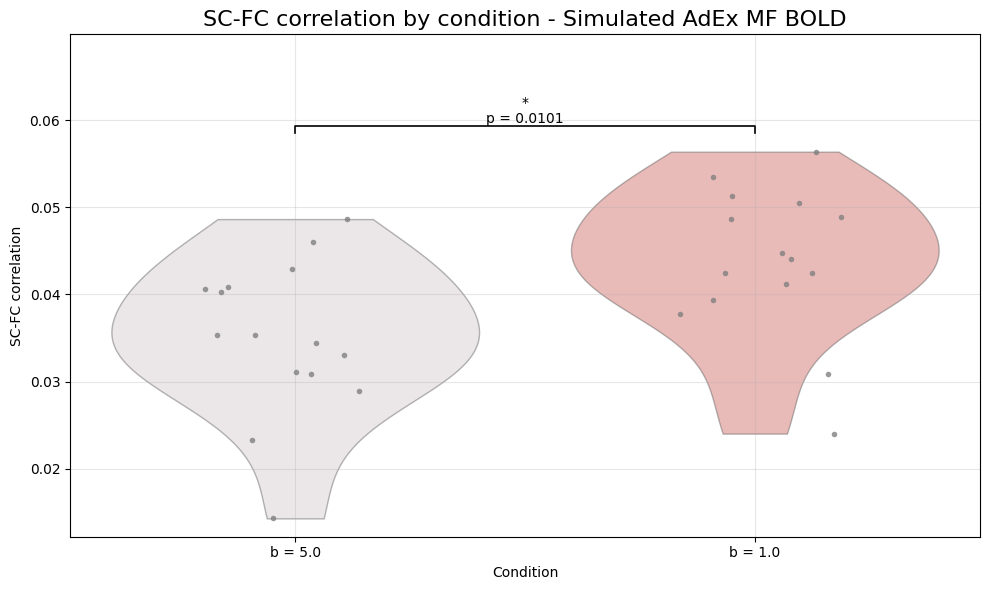

SC-FC correlation by condition - Simulated AdEx MF BOLD
Kruskal-Wallis H = 6.7204, p = 0.009531
Pairwise Mann-Whitney results:
  Condition_1 Condition_2  Mann-Whitney U   p-value
0     b = 5.0     b = 1.0            50.0  0.010122



c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\angelica_scripts\utils.py:210: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.violinplot(


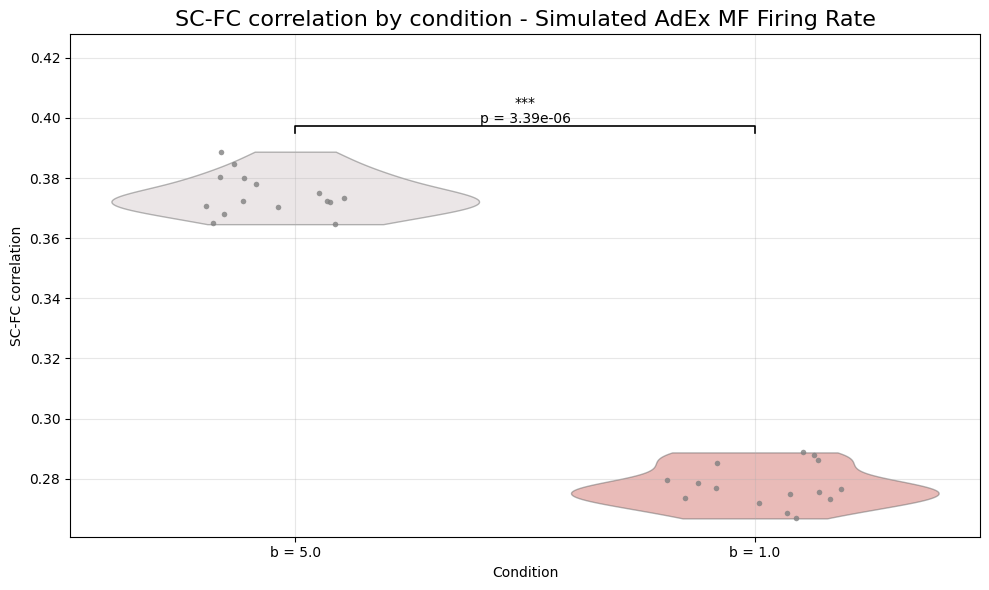

SC-FC correlation by condition - Simulated AdEx MF Firing Rate
Kruskal-Wallis H = 21.7742, p = 3.067e-06
Pairwise Mann-Whitney results:
  Condition_1 Condition_2  Mann-Whitney U   p-value
0     b = 5.0     b = 1.0           225.0  0.000003



In [ ]:
# Plotting SC-FC correlation for BOLD and firing rate conditions separately, with two groups (baseline and reduced b) in each graph

palette = {
    conds[0]: "#D4C6C9",
    conds[1]: "#E1544C"
}

plot_sc_fc_corr(
    sc_fc_corr_bold,
    "SC-FC correlation by condition - Simulated AdEx MF BOLD",
    f"SC_FC_correlation_bold.{graph_format}",
    conds, n_sub, palette, res_dir
)

plot_sc_fc_corr(
    sc_fc_corr_fr,
    "SC-FC correlation by condition - Simulated AdEx MF Firing Rate",
    f"SC_FC_correlation_fr.{graph_format}",
    conds, n_sub, palette, res_dir
    )

c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\angelica_scripts\utils.py:317: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.violinplot(


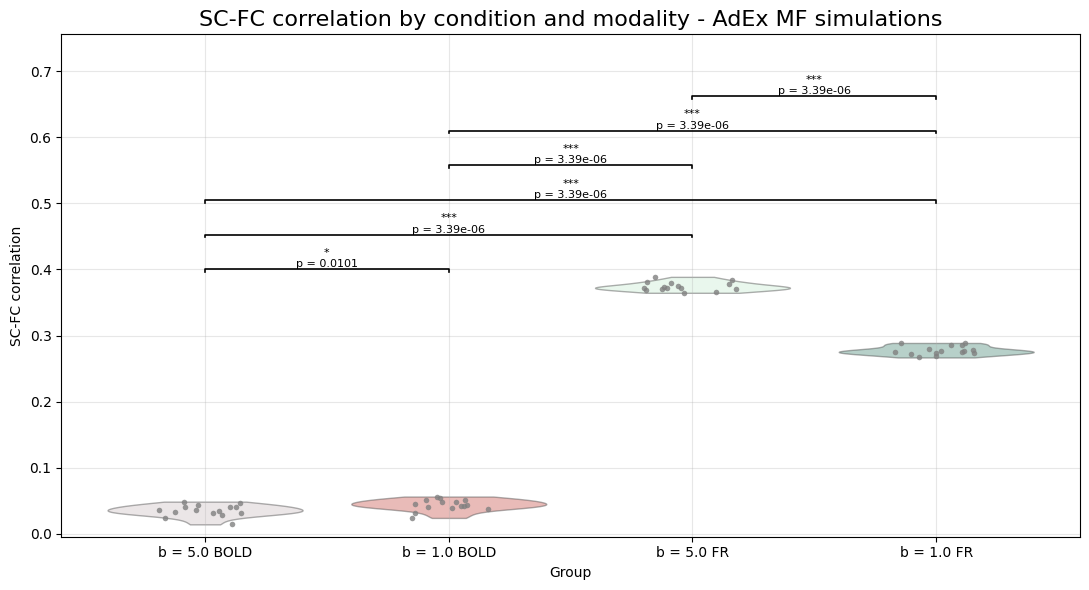

Global Kruskal-Wallis:
H = 51.5027, p = 3.823e-11

Pairwise Mann-Whitney results:
        Group_1       Group_2  Mann-Whitney U   p-value
0  b = 5.0 BOLD  b = 1.0 BOLD            50.0  0.010122
1  b = 5.0 BOLD    b = 5.0 FR             0.0  0.000003
2  b = 5.0 BOLD    b = 1.0 FR             0.0  0.000003
3  b = 1.0 BOLD    b = 5.0 FR             0.0  0.000003
4  b = 1.0 BOLD    b = 1.0 FR             0.0  0.000003
5    b = 5.0 FR    b = 1.0 FR           225.0  0.000003


c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\angelica_scripts\utils.py:317: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.violinplot(


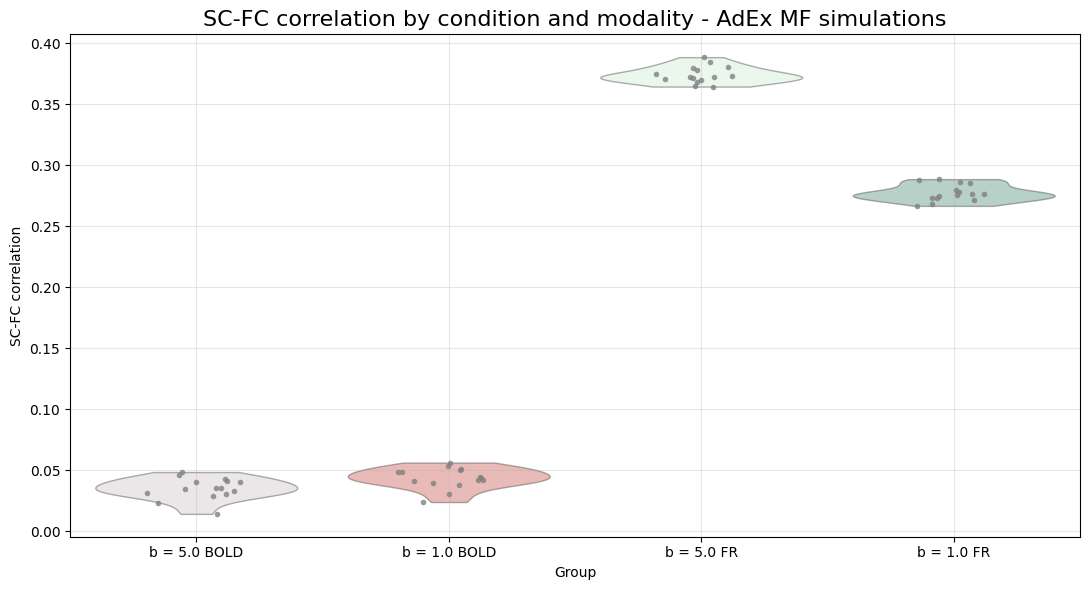

In [14]:
# Plotting all four groups together in one graph
# Assumes SC, Q_data_bold, Q_data_fr, conds, n_sub, n_cond, res_dir, graph_format are already defined

# Build one dataframe with 4 groups
data = pd.DataFrame({
    "Group": (
        [f"{conds[0]} BOLD"] * n_sub +
        [f"{conds[1]} BOLD"] * n_sub +
        [f"{conds[0]} FR"] * n_sub +
        [f"{conds[1]} FR"] * n_sub
    ),
    "SC_FC_correlation": np.concatenate([
        sc_fc_corr_bold[:, 0],
        sc_fc_corr_bold[:, 1],
        sc_fc_corr_fr[:, 0],
        sc_fc_corr_fr[:, 1]
    ])
}).dropna(subset=["SC_FC_correlation"])

order = [f"{conds[0]} BOLD", f"{conds[1]} BOLD", f"{conds[0]} FR", f"{conds[1]} FR"]
palette = {
    f"{conds[0]} BOLD": "#D4C6C9",
    f"{conds[1]} BOLD": "#E1544C",
    f"{conds[0]} FR": "#C9F2D4",
    f"{conds[1]} FR": "#519E8A",
}

# Plotting all four groups together (with Mann-Whitney pairwise comparisons and global Kruskal-Wallis test and with no statistical comparison)
plot_sc_fc_corr_bold_fr(data, order, res_dir, palette, graph_format, stat_bars=True)

plot_sc_fc_corr_bold_fr(data, order, res_dir, palette, graph_format, stat_bars=False) 

### Multivariate Ornstein-Uhlenbeck (MOU) fitting 
cf. [Gilson et al., 2023](https://doi.org/10.1103/PhysRevE.107.024121) for algorithm details

  0%|          | 0/15 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.000000000084543
optimisation step: 0 ; model error = 0.7815326480272234
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000015139863
optimisation step: 1 ; model error = 0.7970408615404782
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000000740707
optimisation step: 2 ; model error = 0.792146452896511
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.000000000107592
optimisation step: 3 ; model error = 0.7915214435908569
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000002485991
optimisation step: 4 ; model error = 0.7925503257623626
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.00000000020085
optimisation step: 5 ; model error = 0.7922048320716948
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000002771916
optimisation step: 6 ; model error = 0.79263690832

  7%|▋         | 1/15 [00:01<00:19,  1.37s/it]

optimisation step: 15 ; model error = 0.7945185852107621
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000002845664
optimisation step: 16 ; model error = 0.7942838344881826
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000003034204
optimisation step: 17 ; model error = 0.7945715393082776
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.000000000365212
optimisation step: 18 ; model error = 0.7949959522739058
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000003693235
optimisation step: 19 ; model error = 0.7949451185063934
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000003384275
optimisation step: 20 ; model error = 0.7947607858620711
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.0000000002979899
optimisation step: 21 ; model error = 0.7948042514041092
Q_data_temp shape: (2, 68, 68)
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 1.

 13%|█▎        | 2/15 [00:02<00:13,  1.05s/it]

...

optimisation step: 95 ; model error = 0.17968905916800504
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.012965719138162813
optimisation step: 96 ; model error = 0.17954399841050506
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.01296012564662354
optimisation step: 97 ; model error = 0.17941101814925092
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.012954572559973322
optimisation step: 98 ; model error = 0.1792902649824321
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.012949059576899484
optimisation step: 99 ; model error = 0.17918188459468606
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.012943586400128819
optimisation step: 100 ; model error = 0.17908602161528983
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.012938152736351188
optimisation step: 101 ; model error = 0.17900281947566982
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.01293275829

 93%|█████████▎| 14/15 [02:57<00:09,  9.36s/it]

optimisation step: 102 ; model error = 0.17589199436182296
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.013000746160241649
optimisation step: 103 ; model error = 0.17576527455806398
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.012995630932652416
optimisation step: 104 ; model error = 0.17564936561926806
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.01299055198213074
optimisation step: 105 ; model error = 0.1755443764105878
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.012985509053300957
optimisation step: 106 ; model error = 0.17545041458721494
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.012980501893858631
optimisation step: 107 ; model error = 0.17536758649193446
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.012975530254516266
optimisation step: 108 ; model error = 0.17529599705293664
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.012970

100%|██████████| 15/15 [03:01<00:00, 12.10s/it]

optimisation step: 106 ; model error = 0.17820514051546552
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.01310265771502409
optimisation step: 107 ; model error = 0.1781617313092571
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.01309776397349025
optimisation step: 108 ; model error = 0.17812961233811442
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.013092903507842098
optimisation step: 109 ; model error = 0.1781088828755253
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.01308807608573244
optimisation step: 110 ; model error = 0.1780996405426547
Consistency between Q0 and Q1 for current J (Q1 - Q0*exp(J)/Q1): 0.013083281477660849
optimisation step: 111 ; model error = 0.1781019812134742


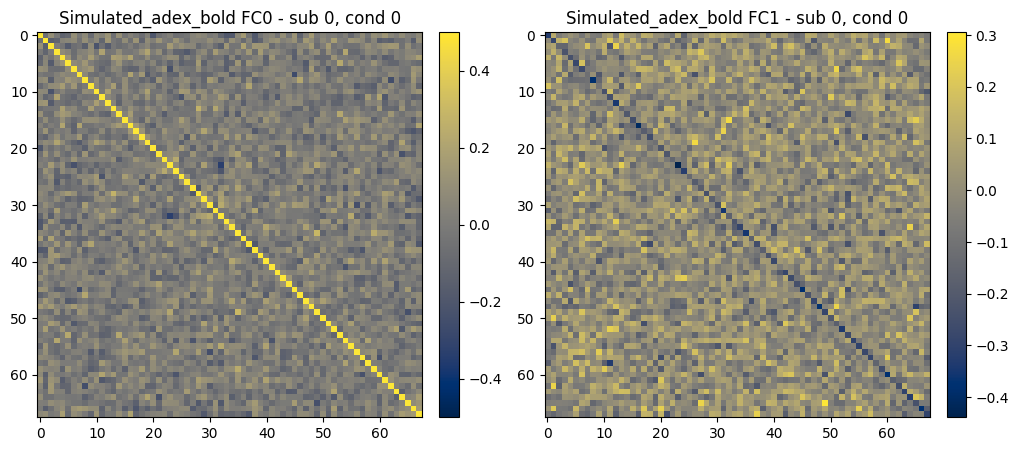

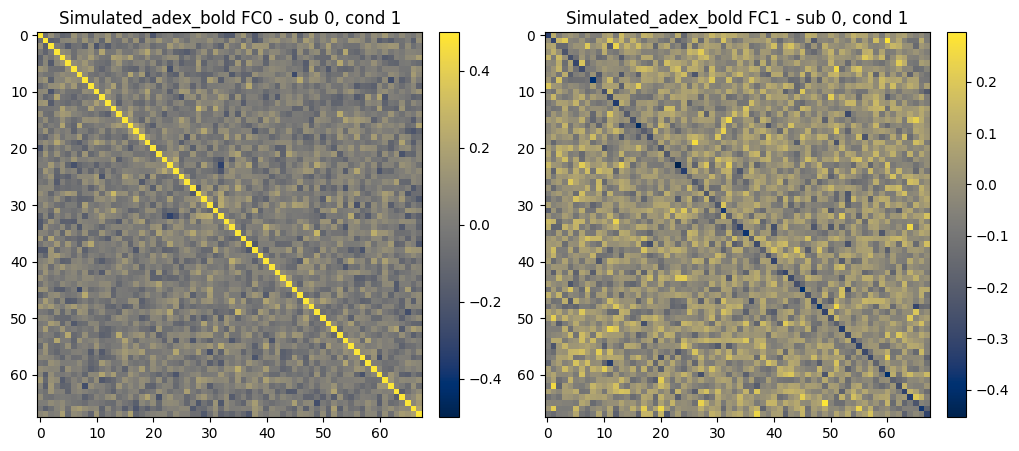

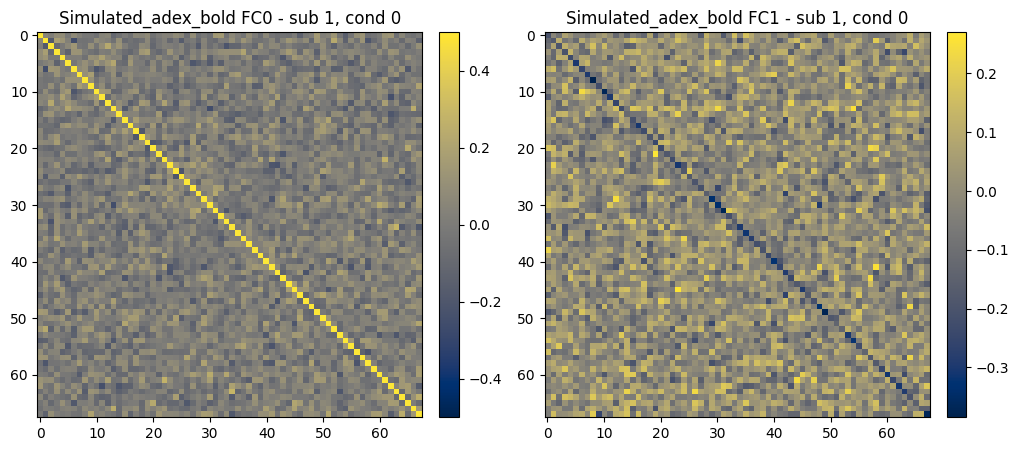

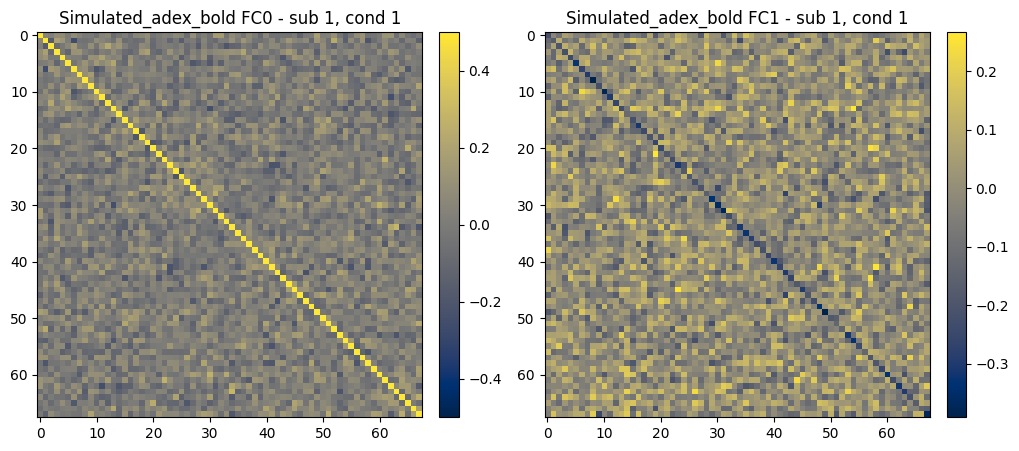

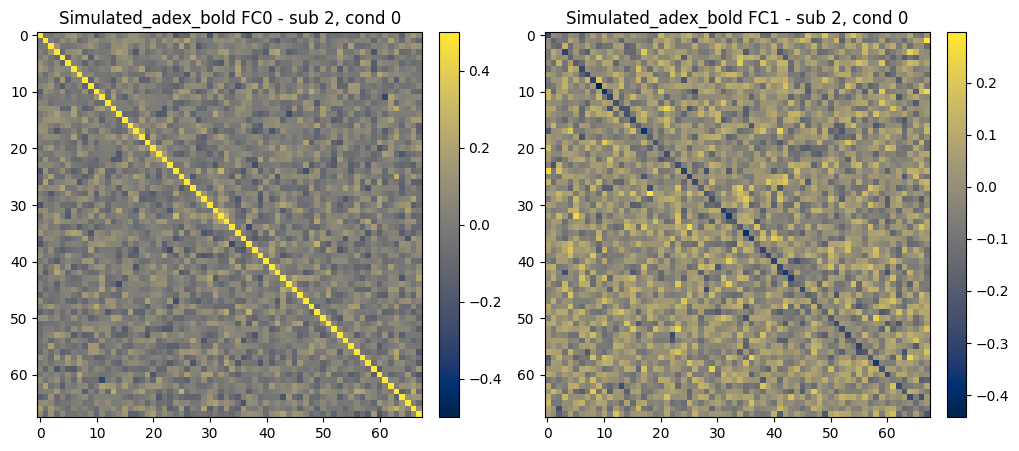

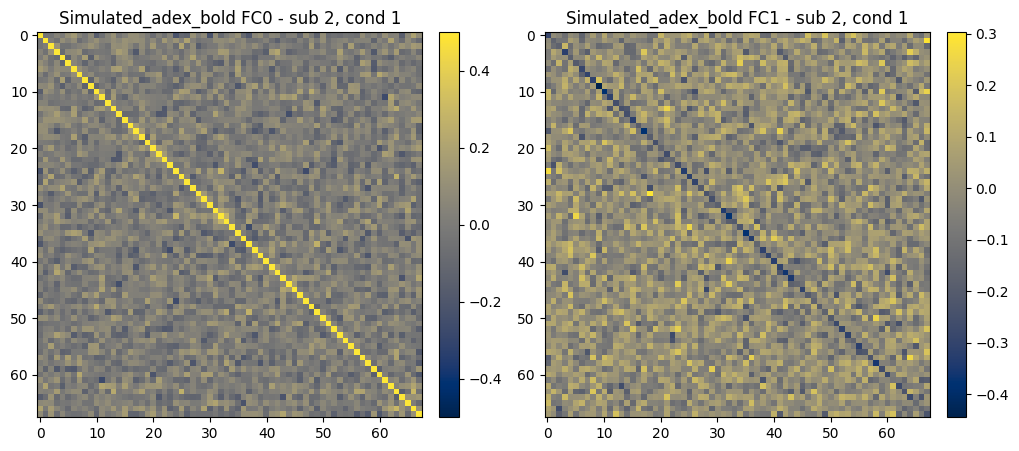

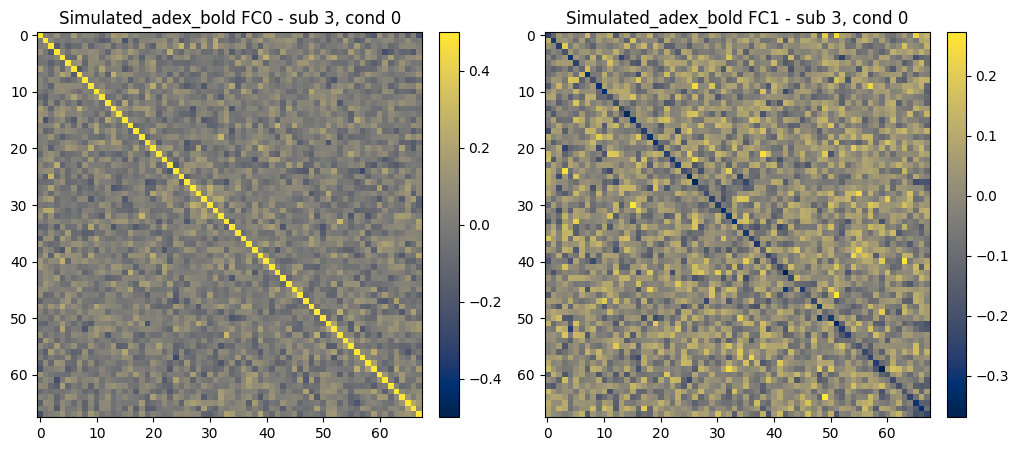

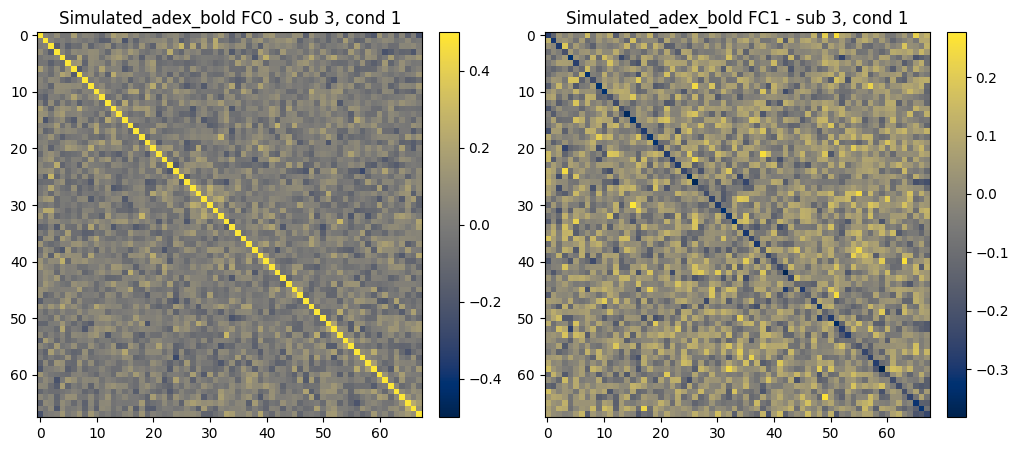

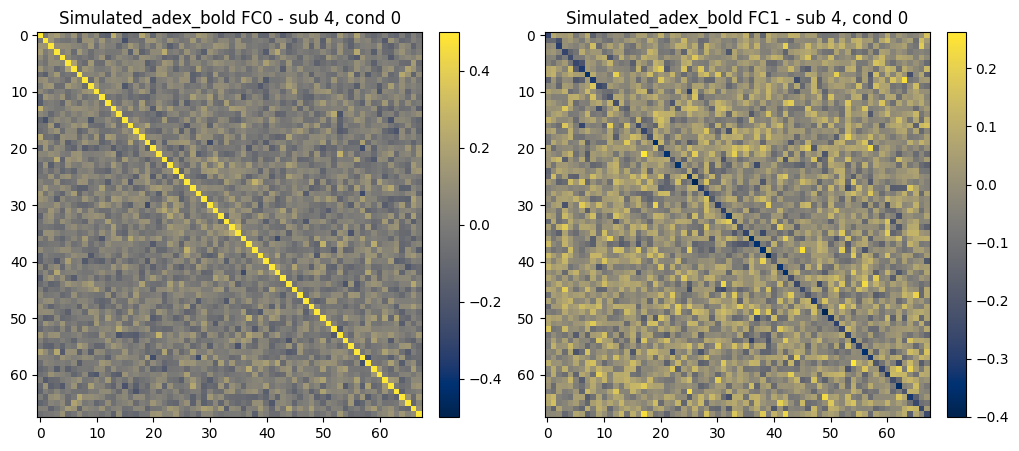

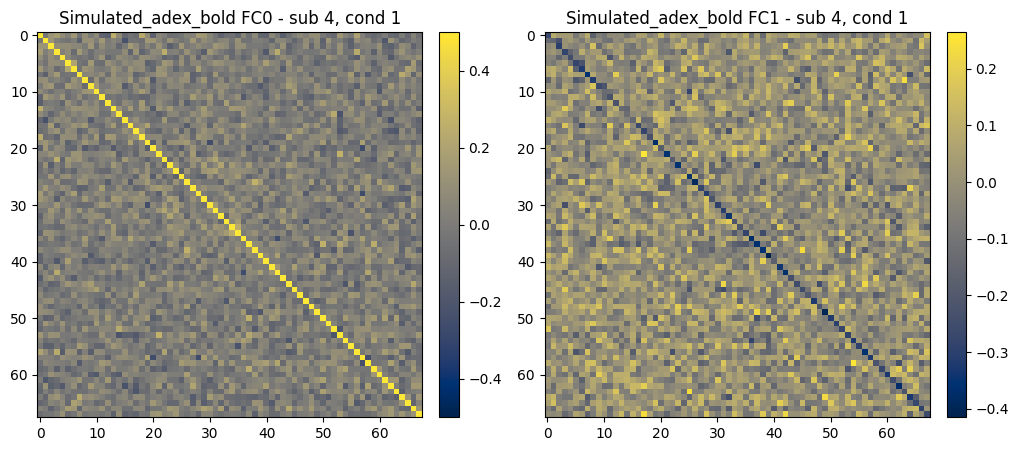

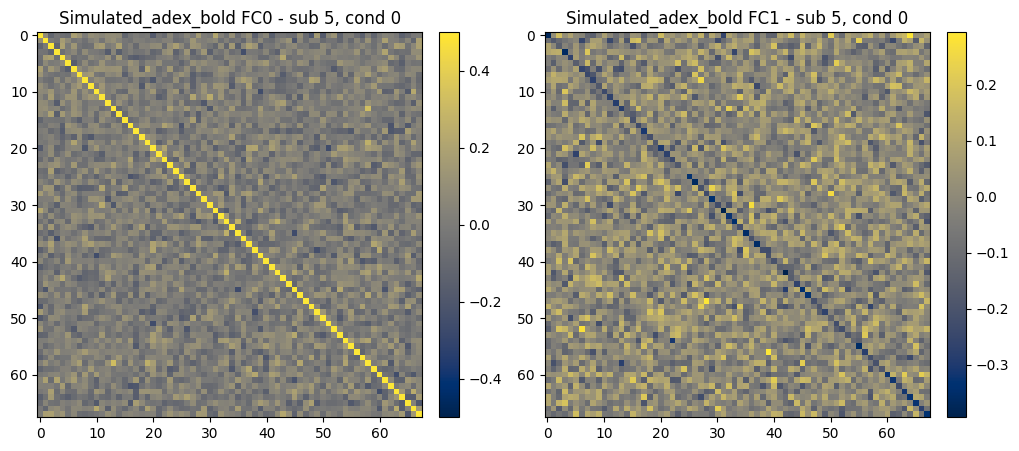

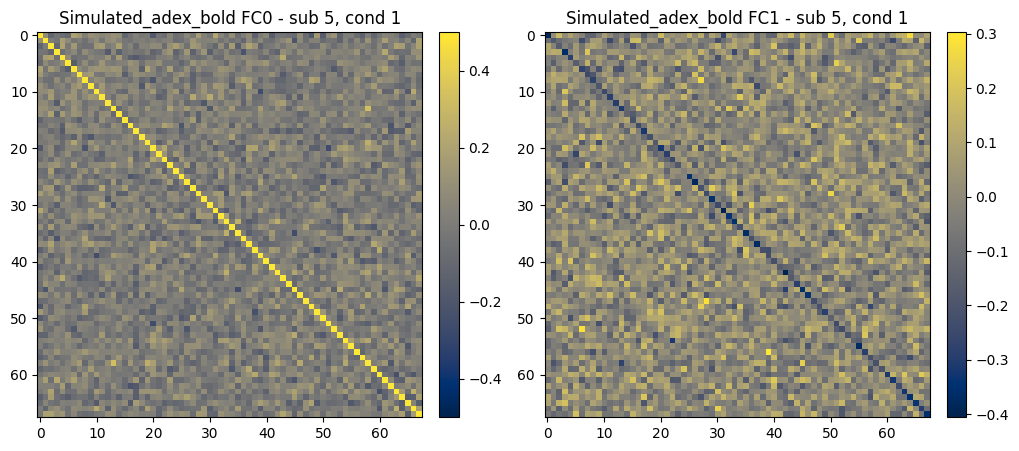

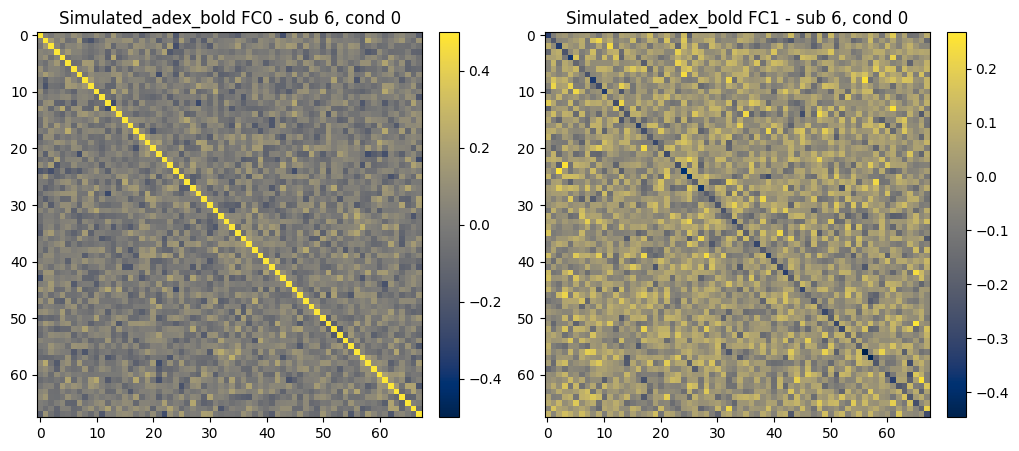

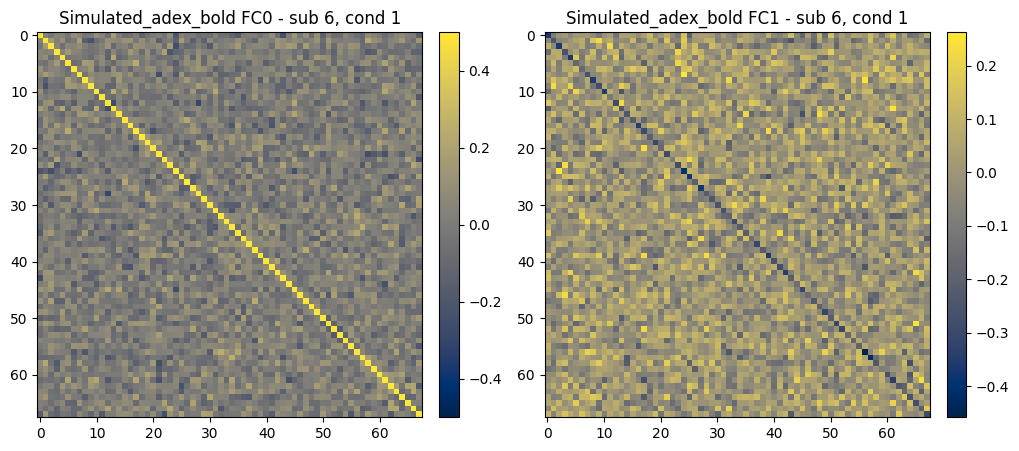

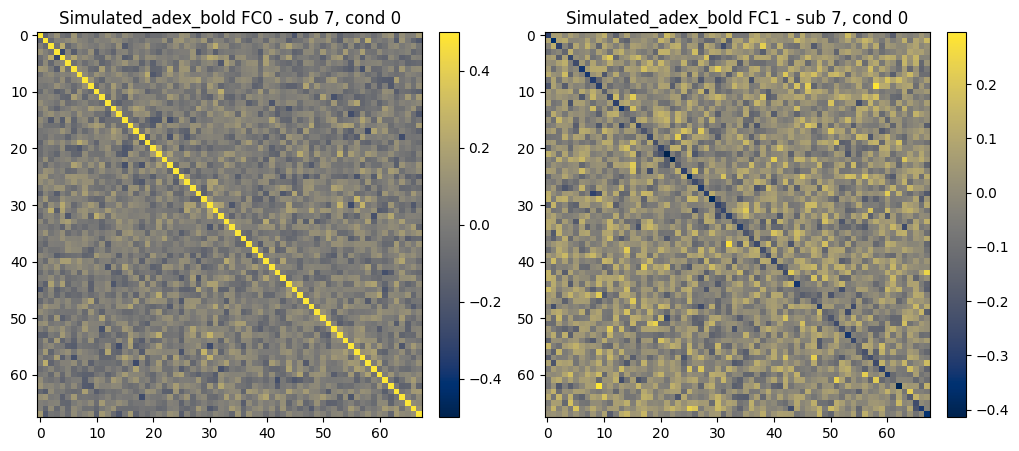

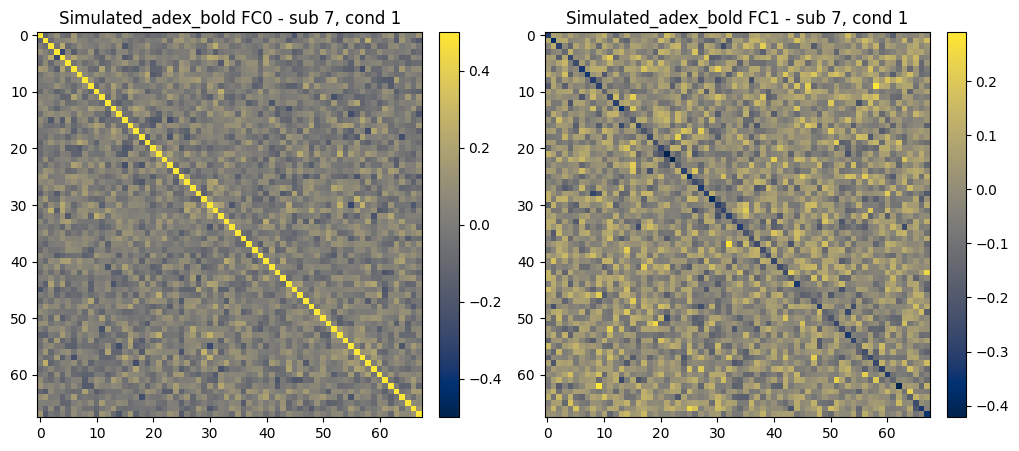

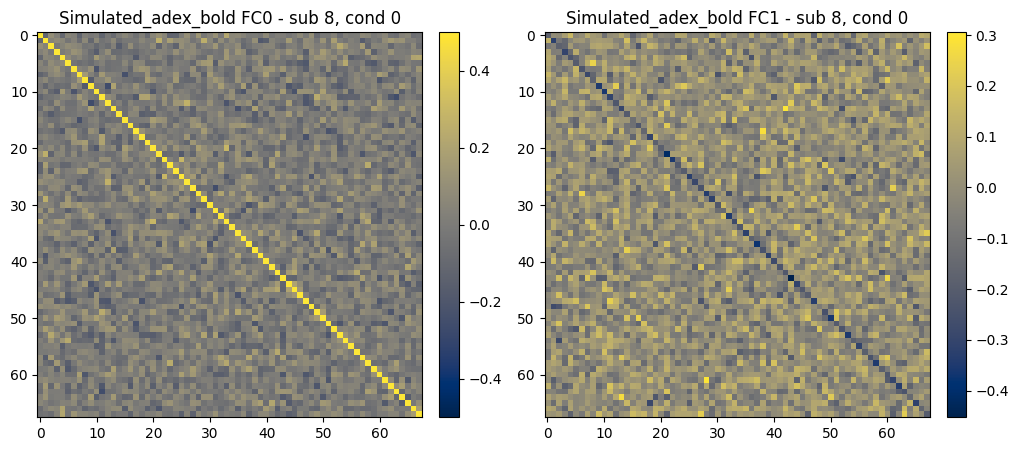

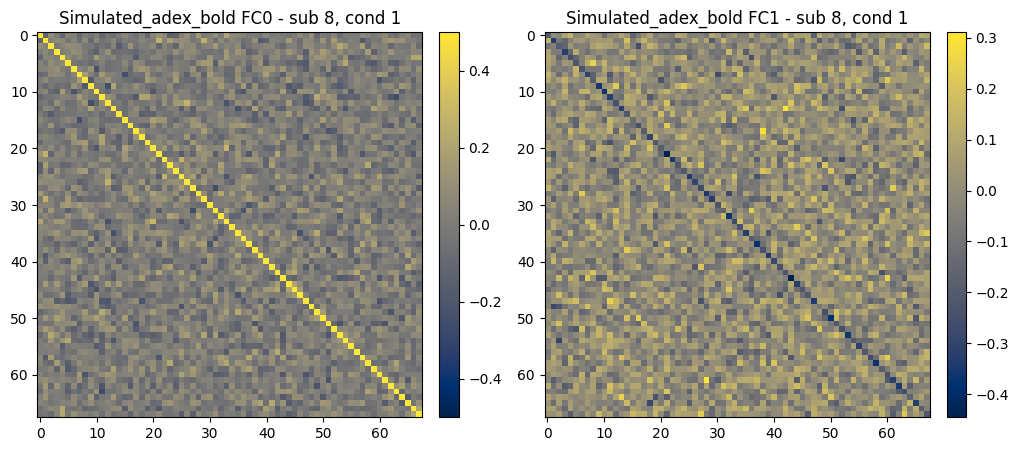

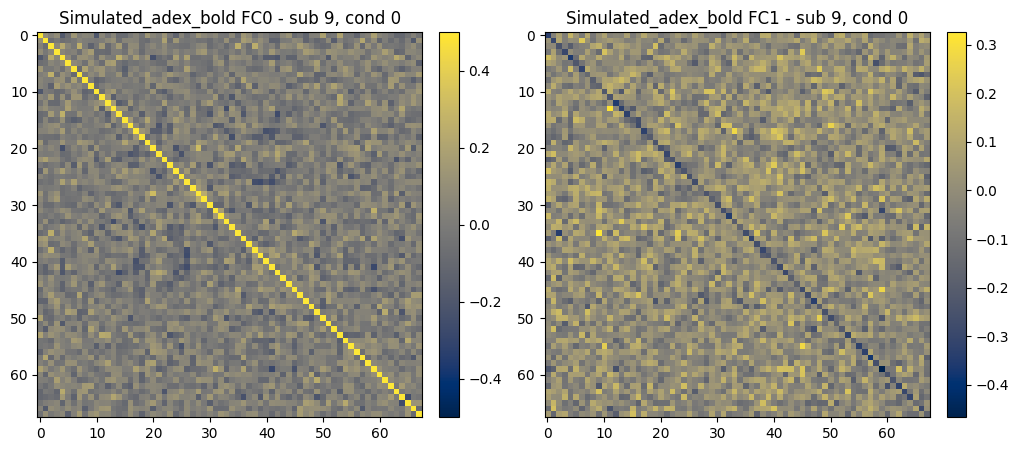

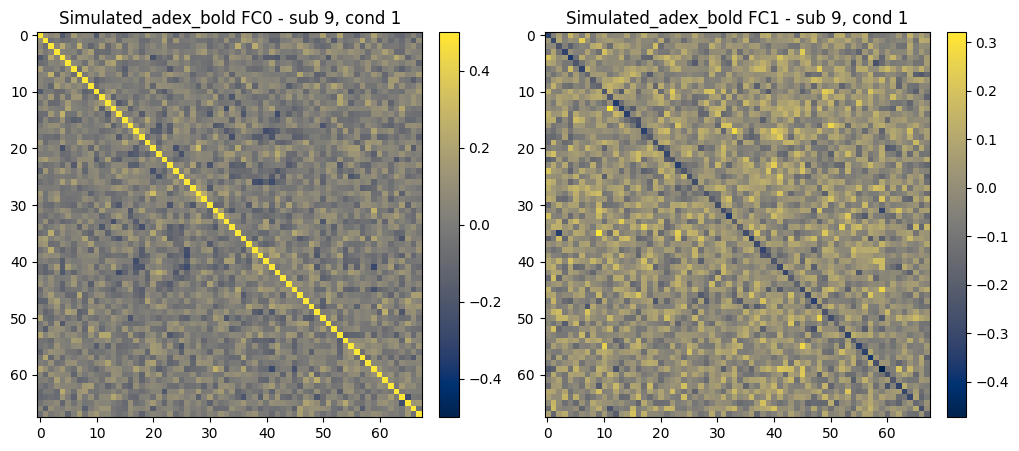

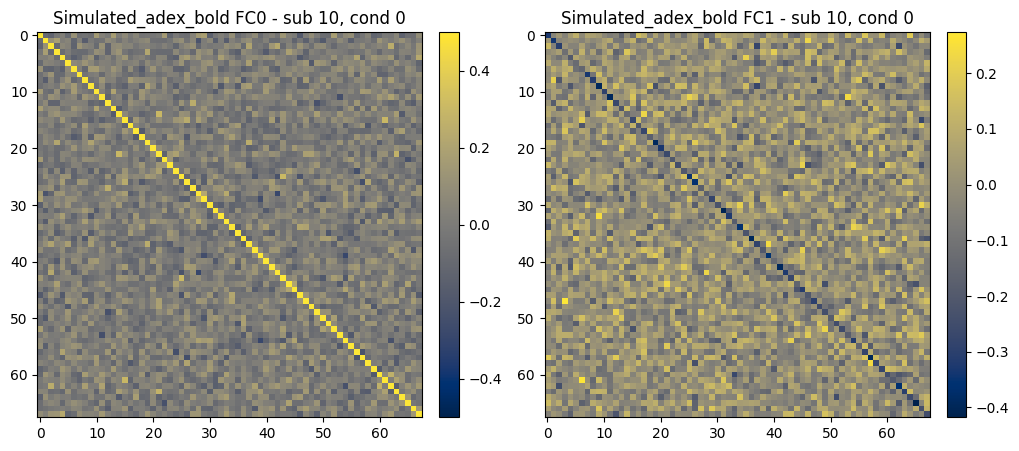

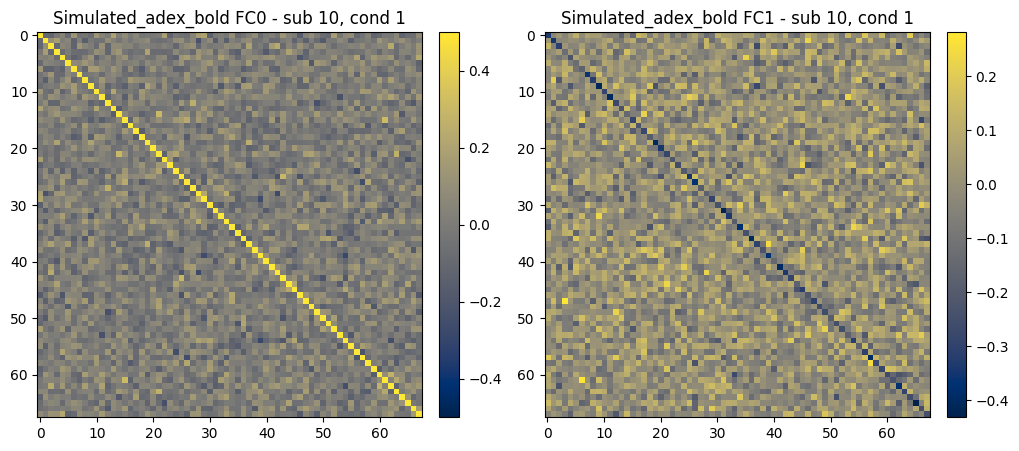

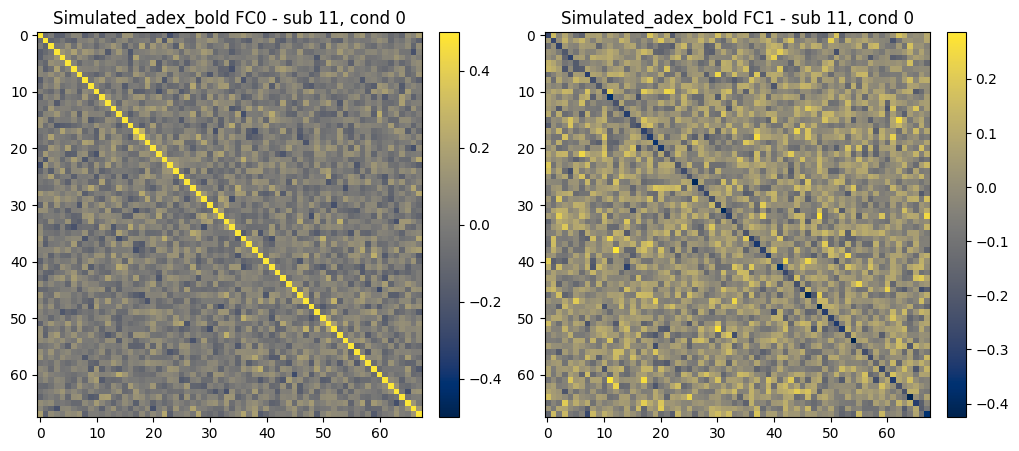

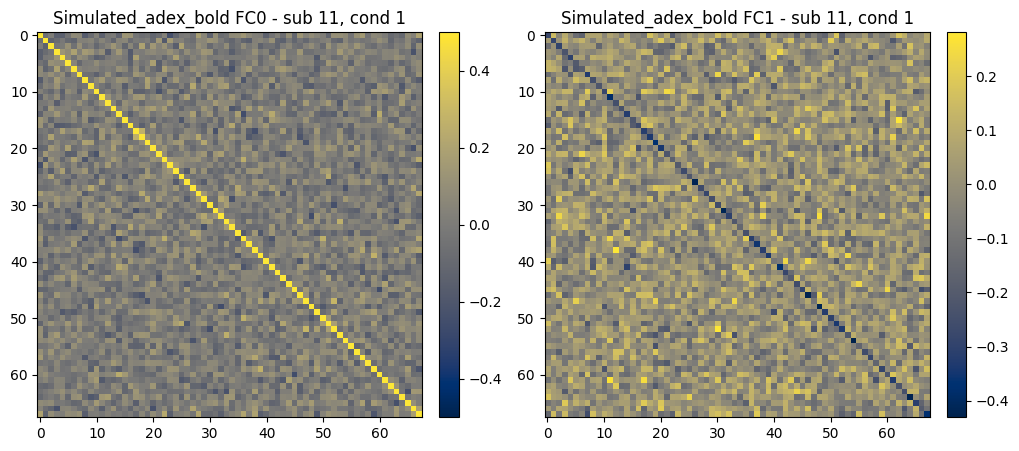

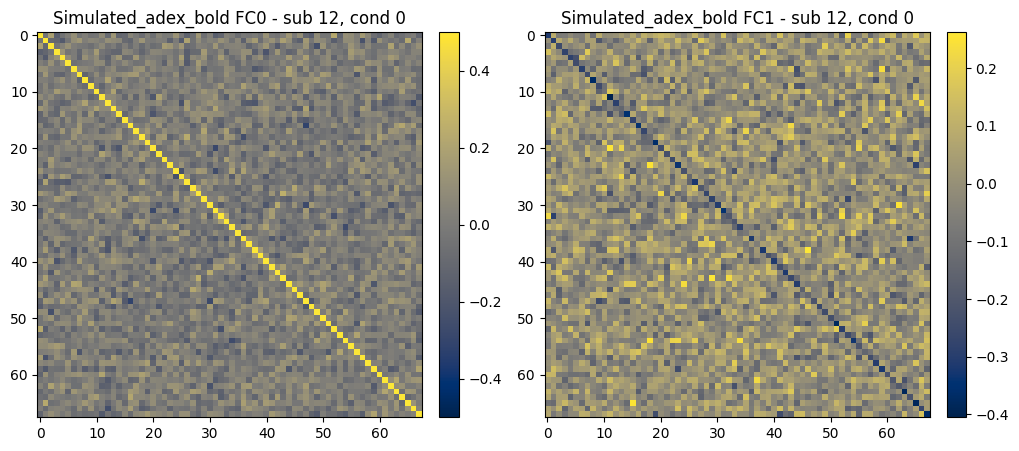

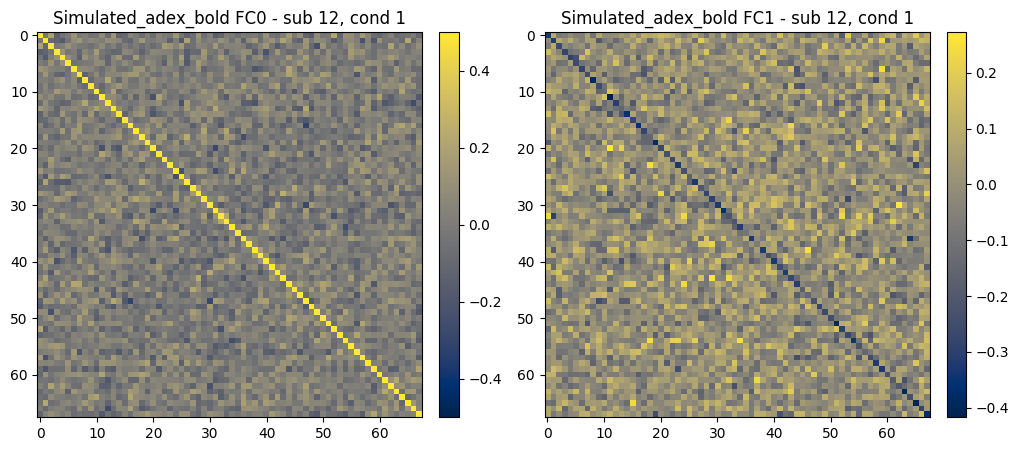

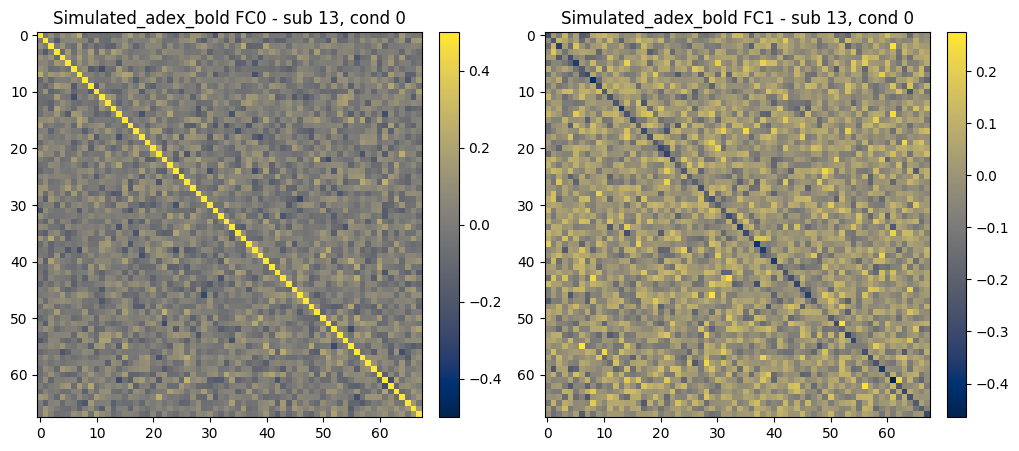

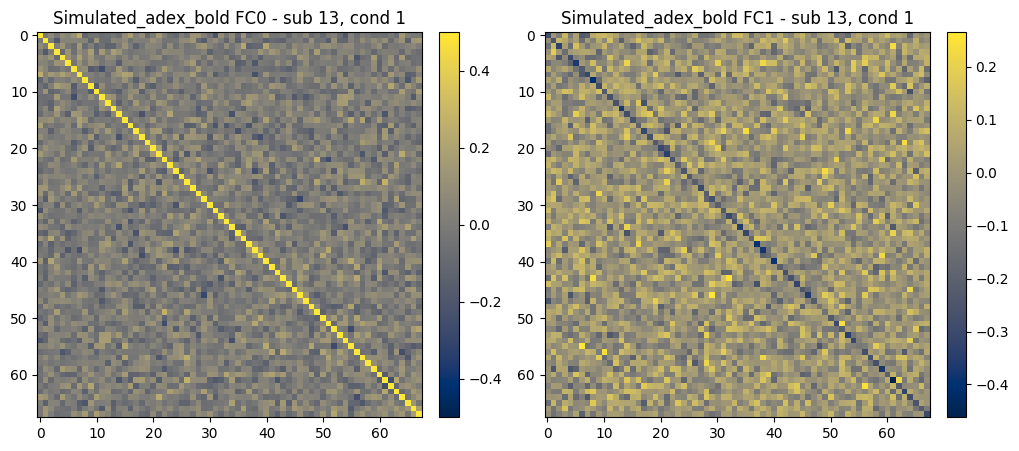

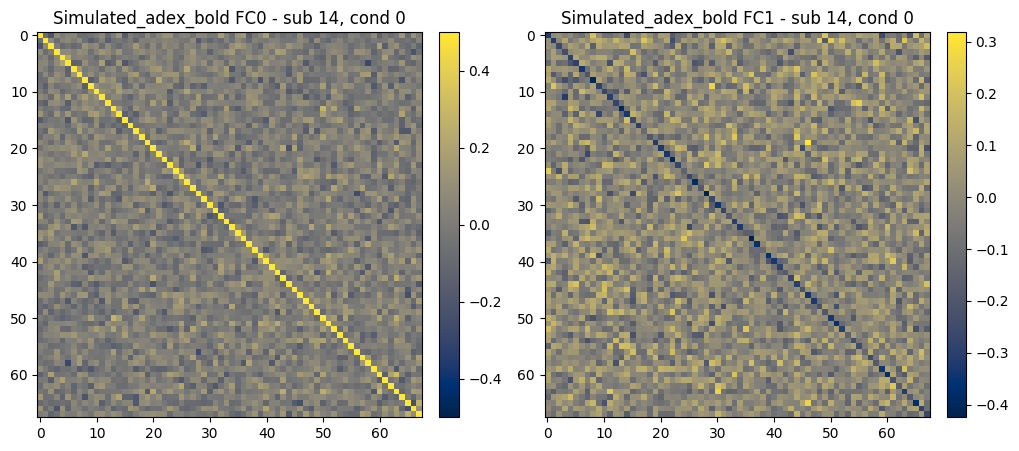

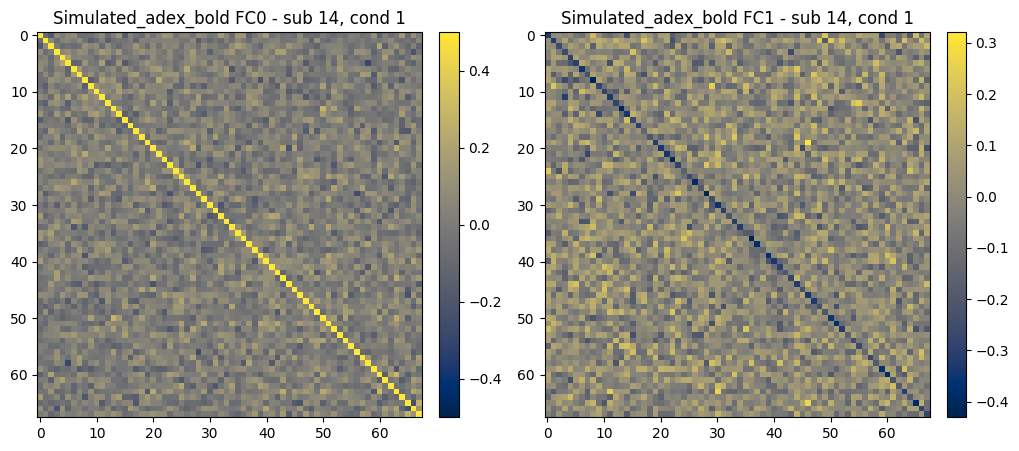

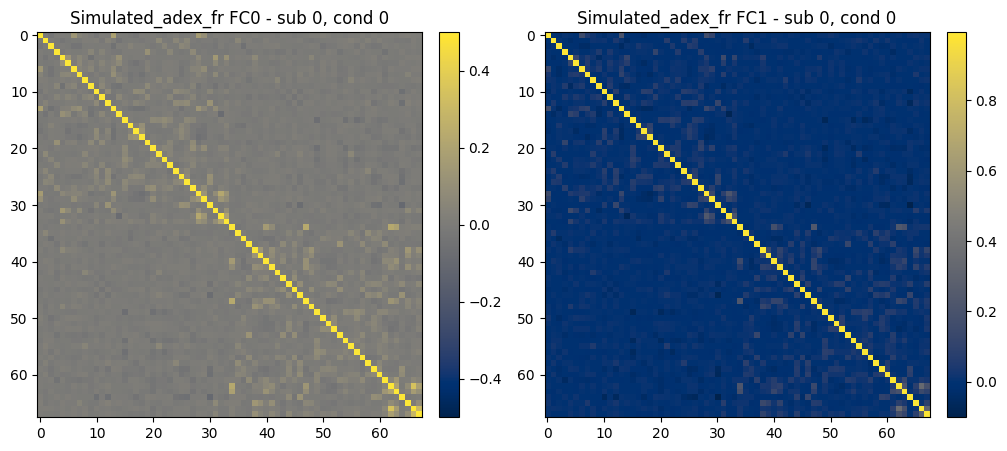

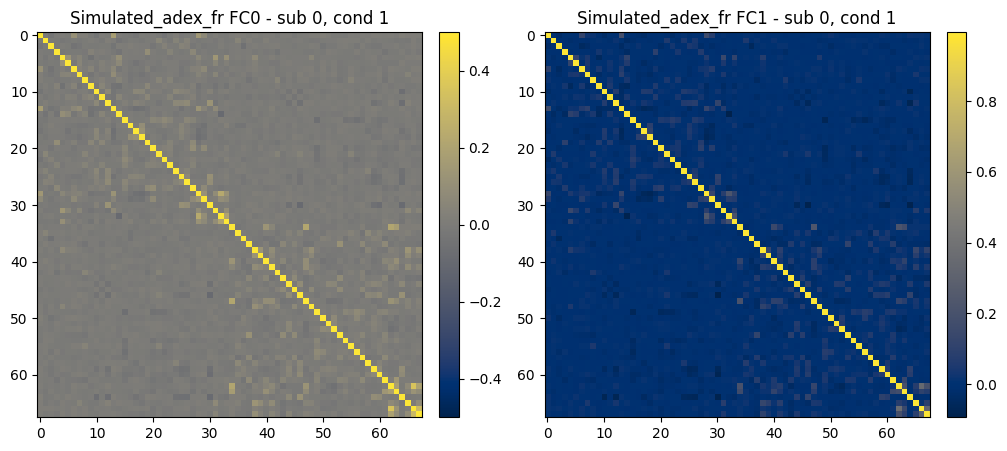

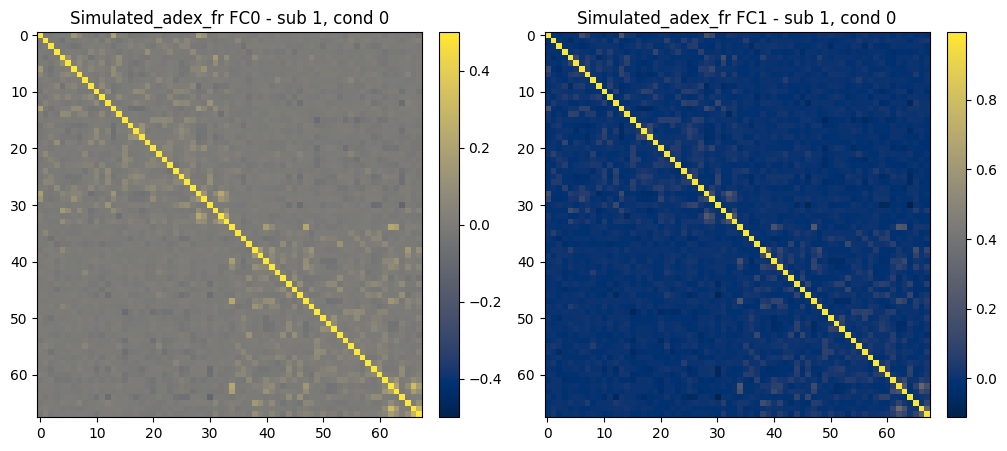

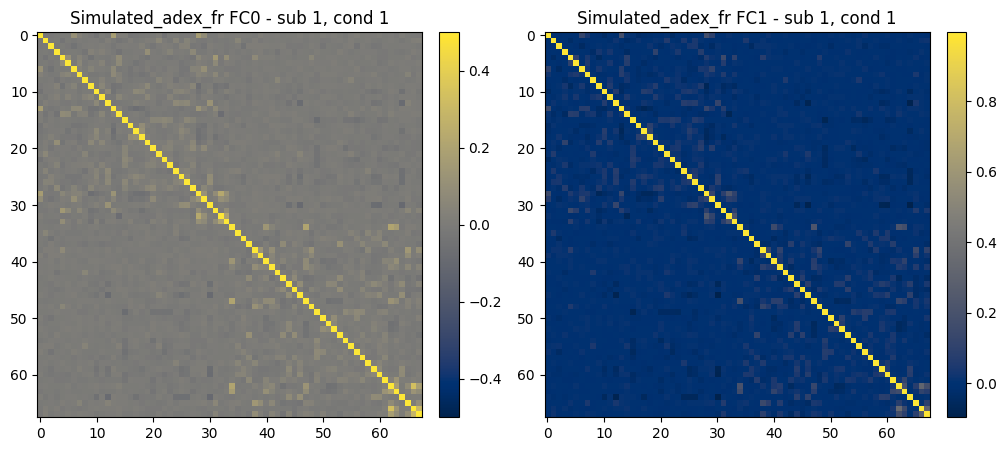

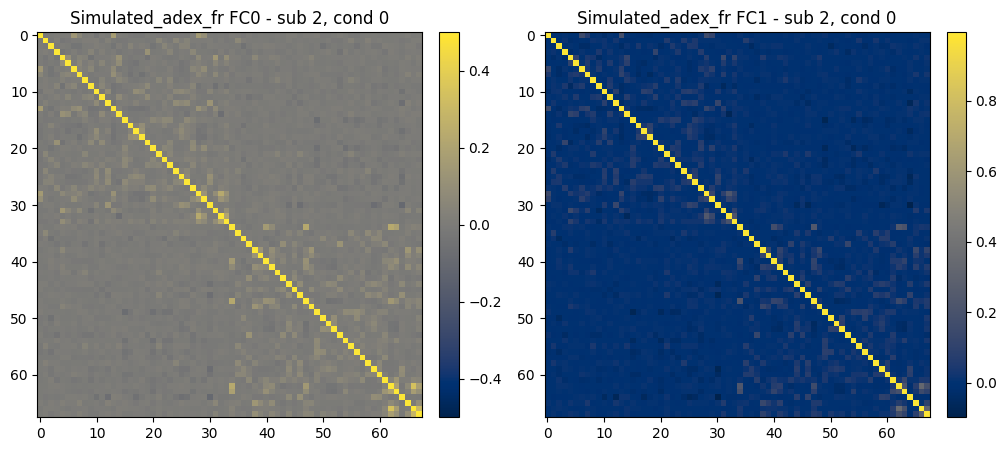

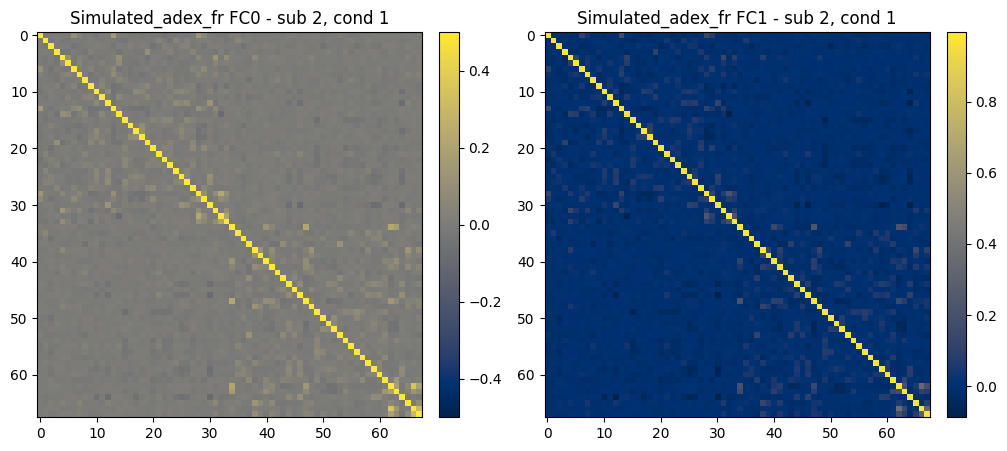

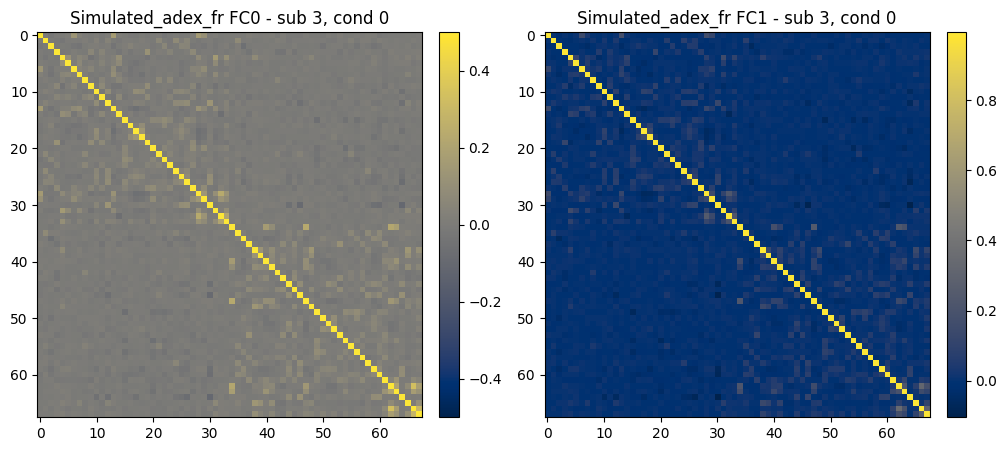

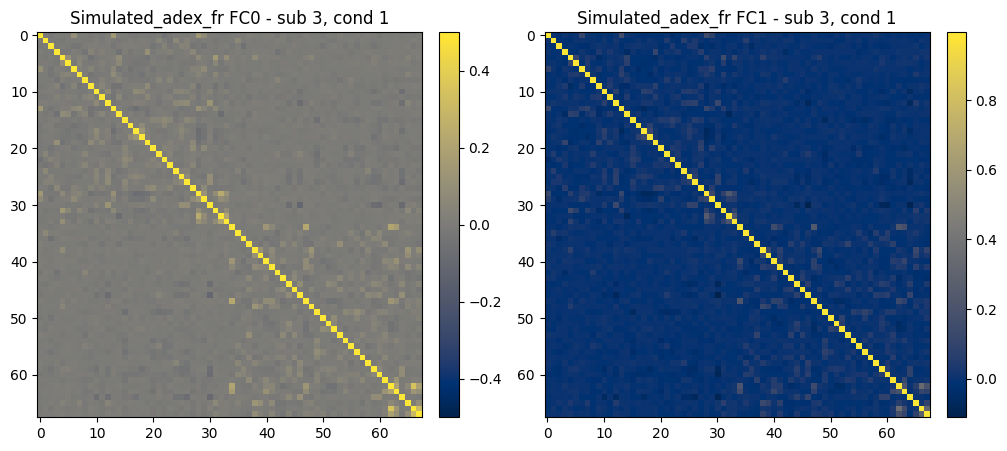

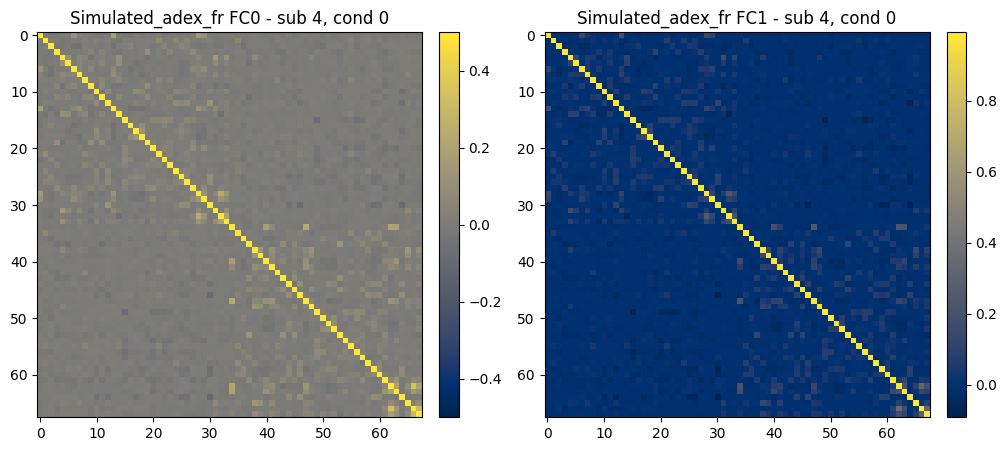

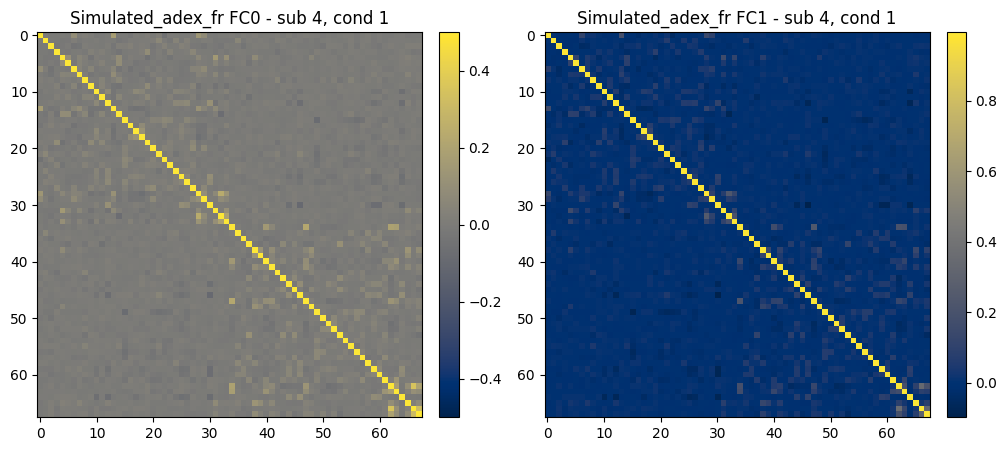

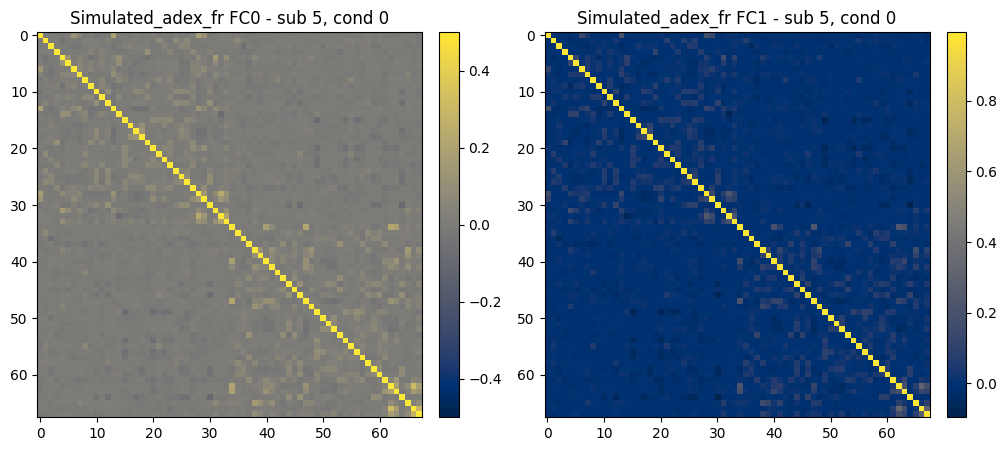

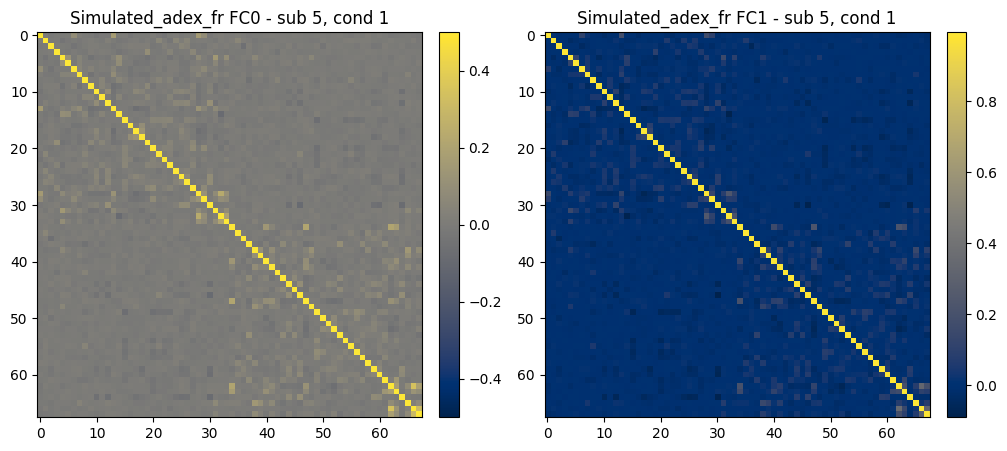

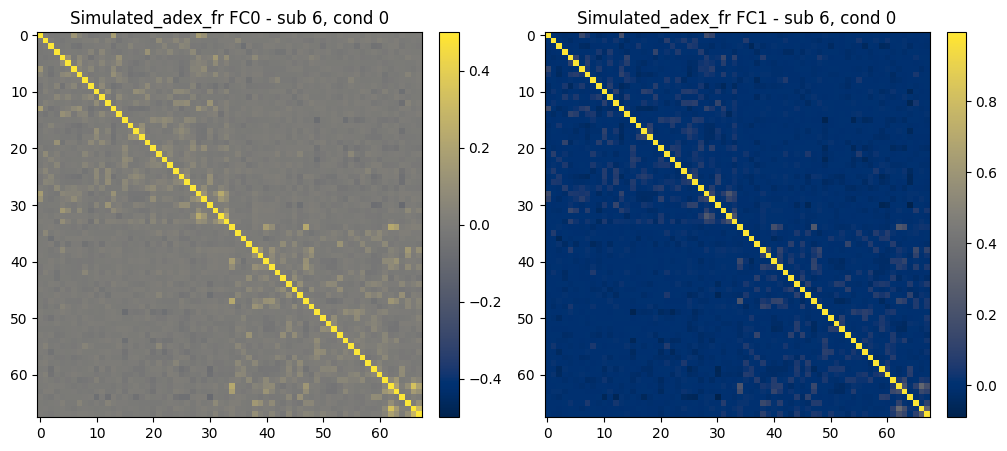

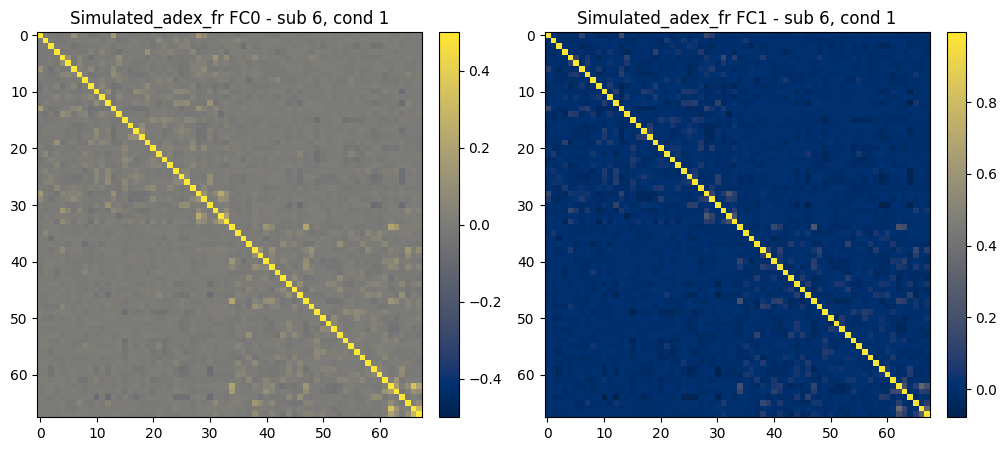

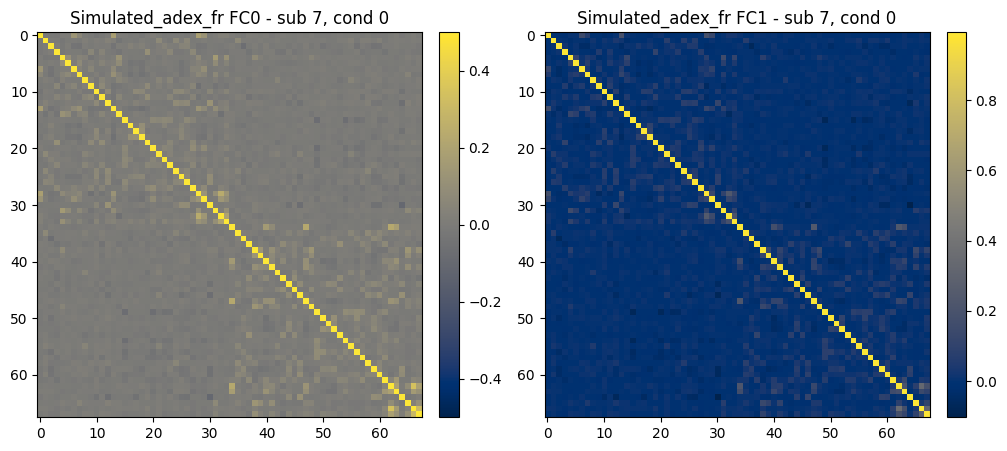

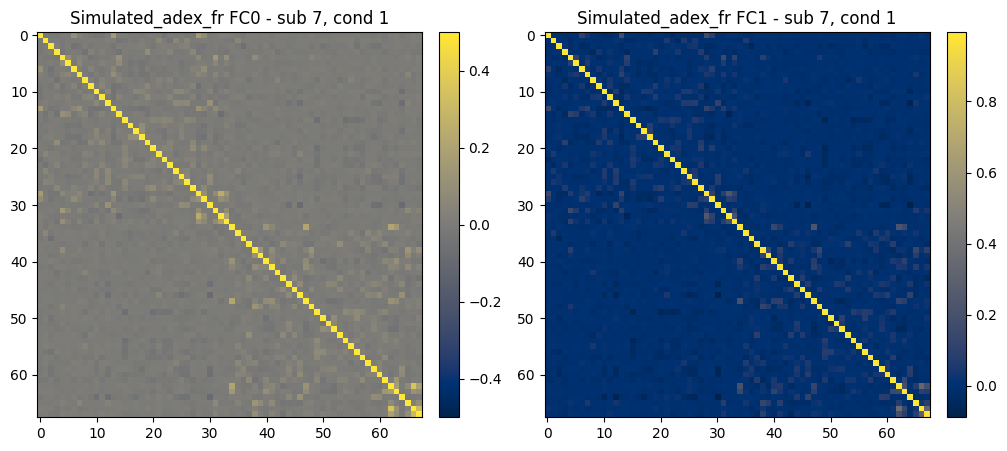

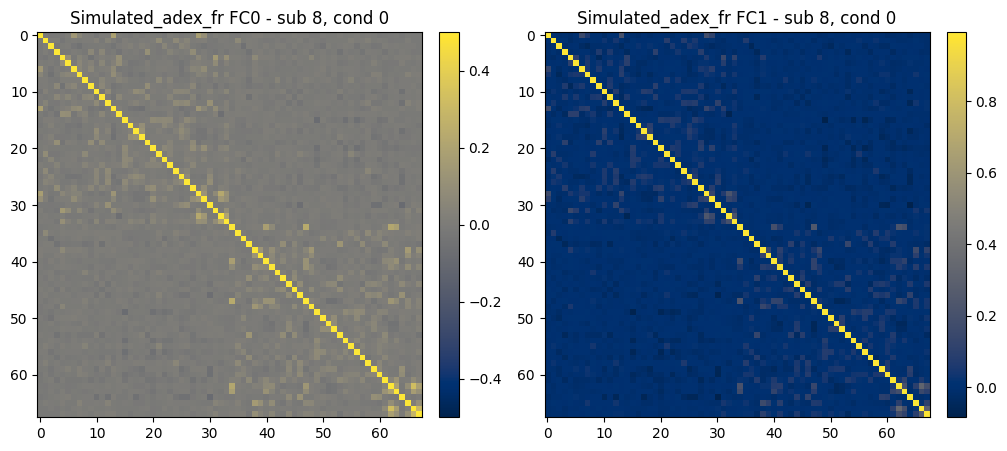

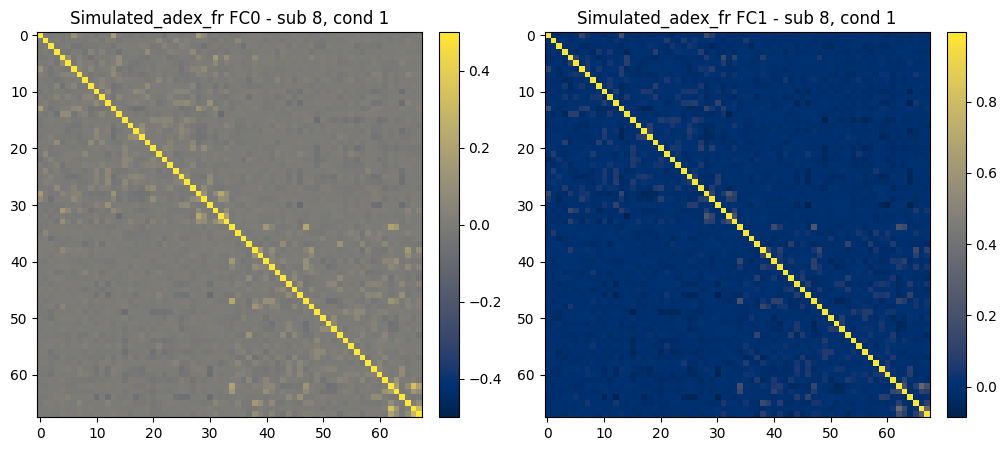

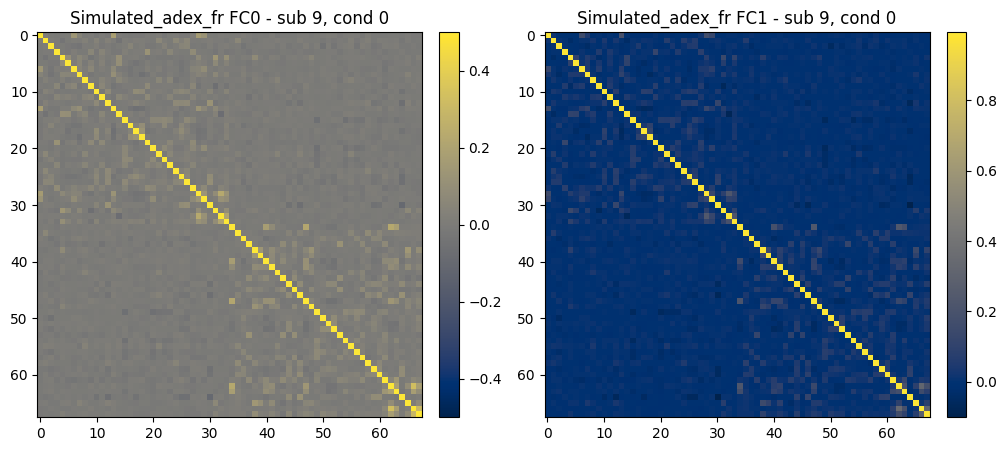

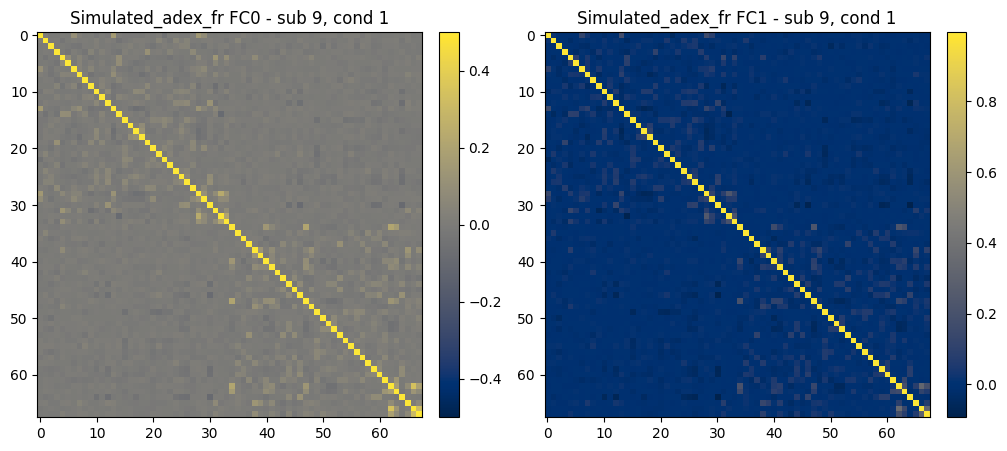

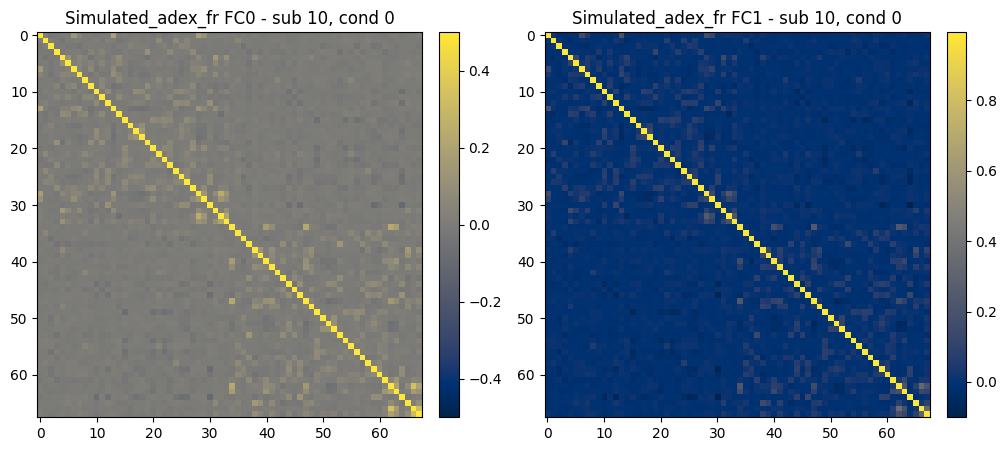

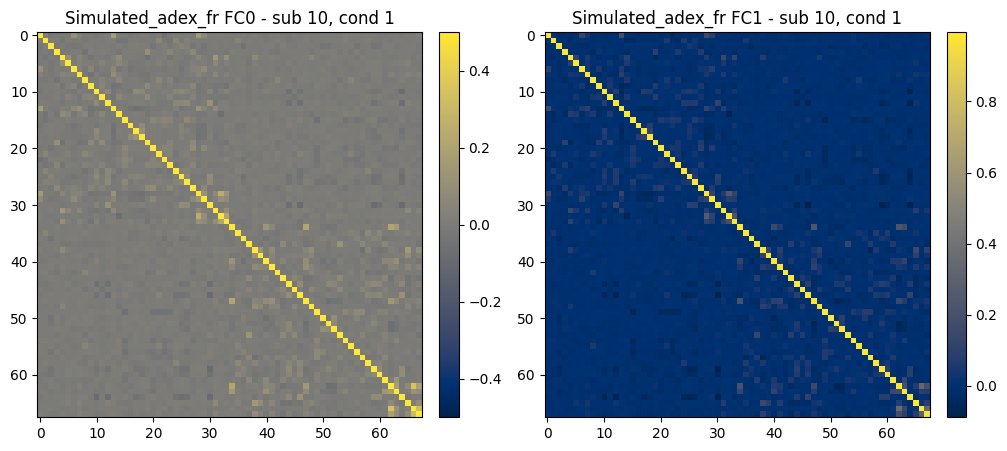

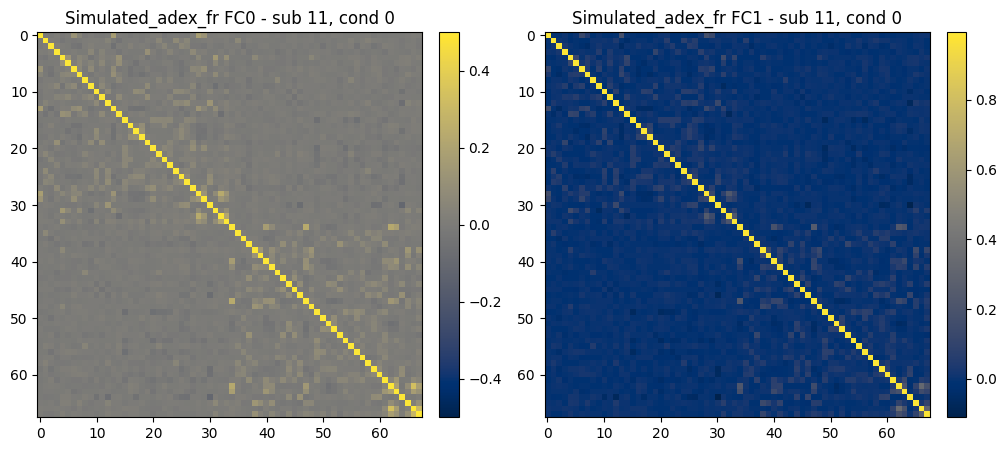

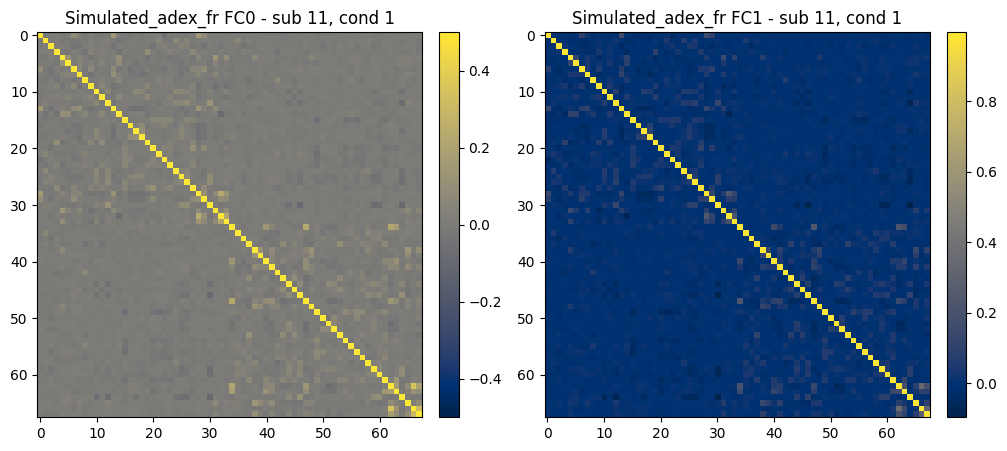

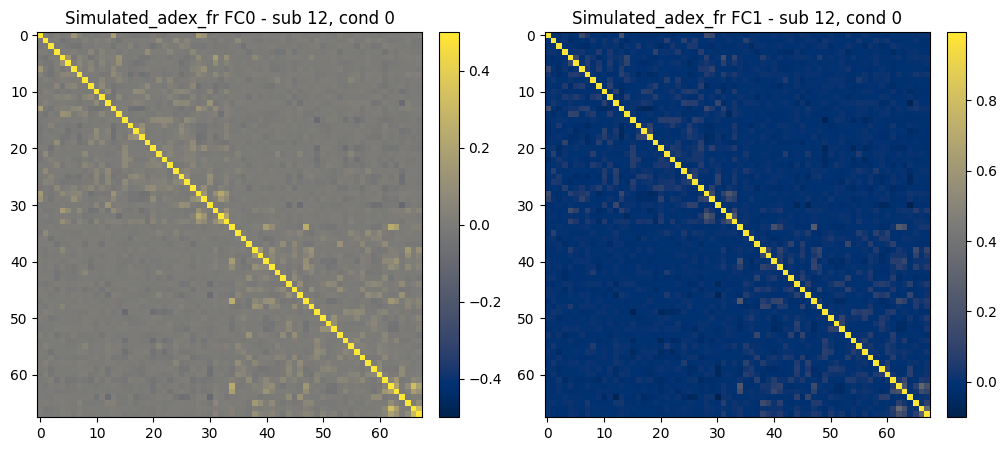

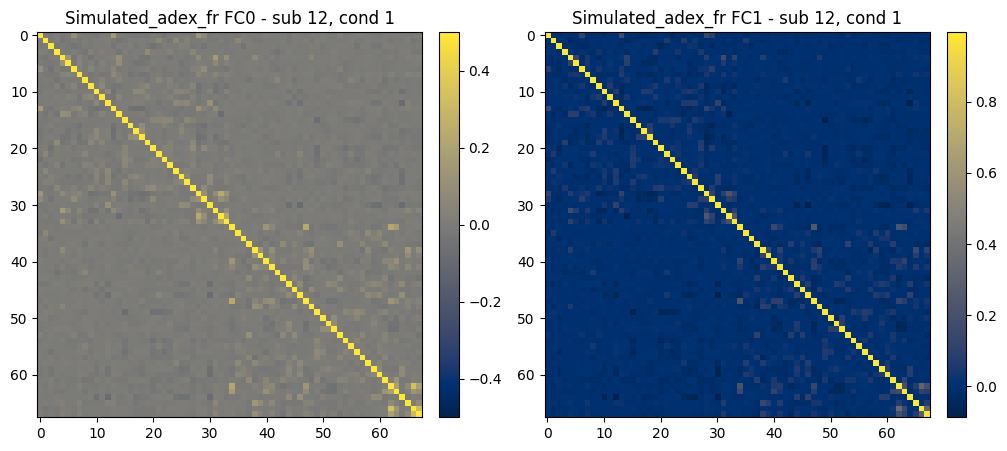

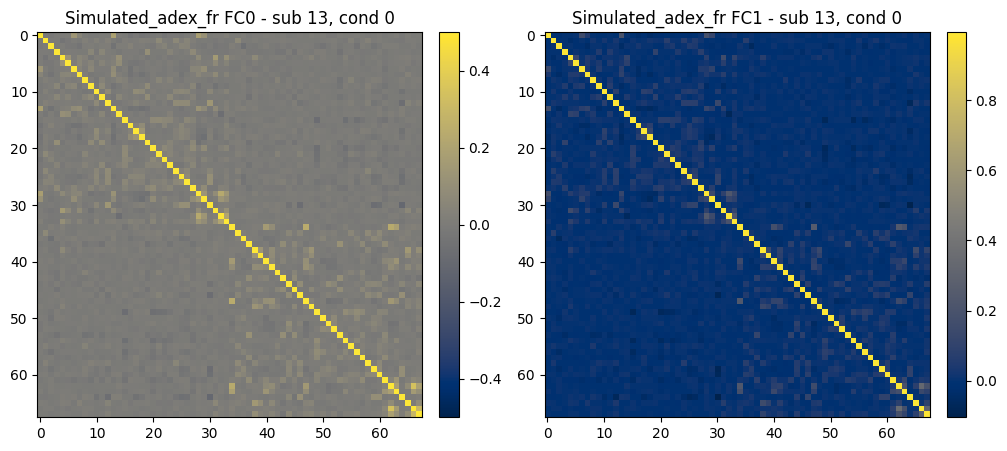

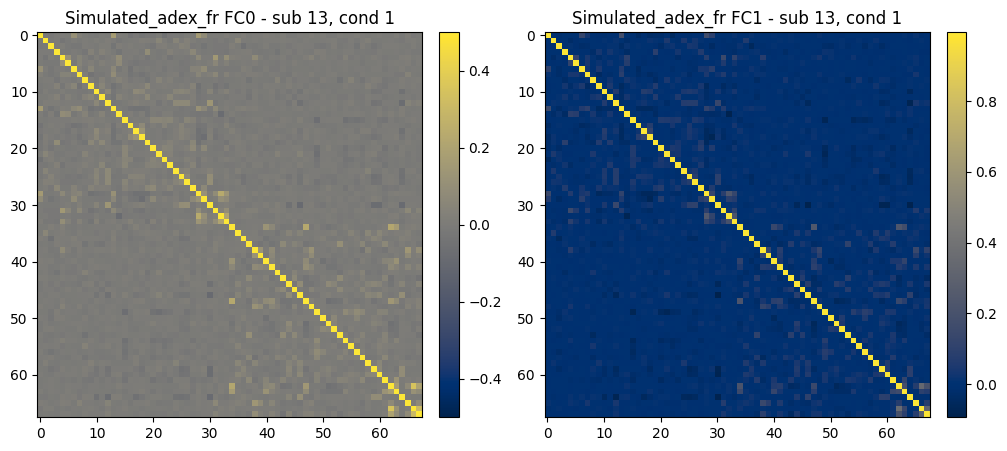

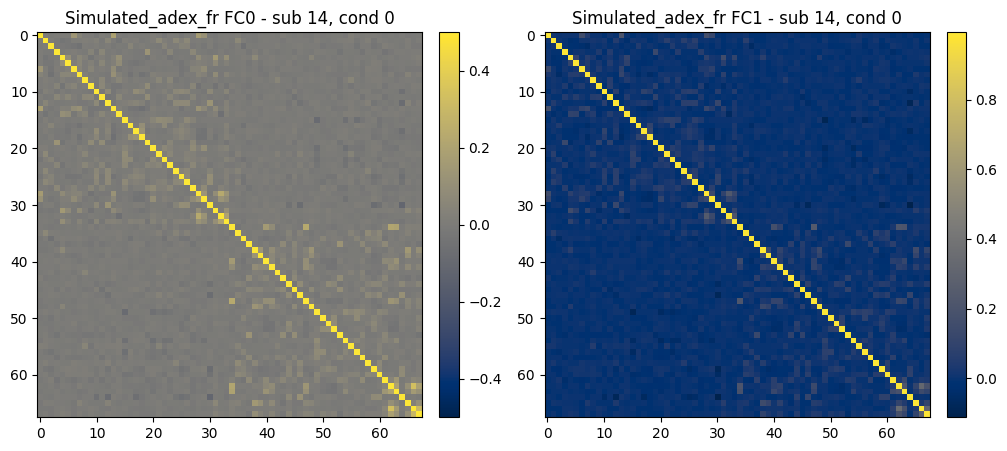

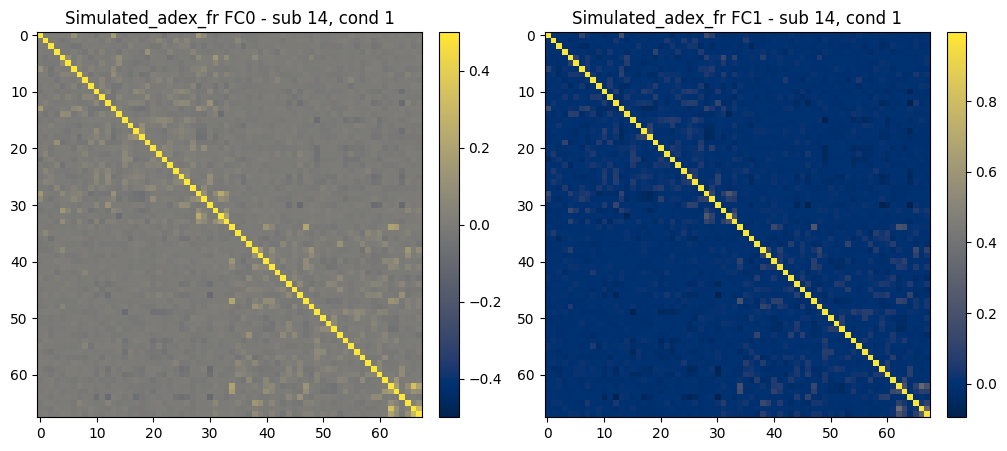

In [15]:
# Mou fitting
min_val_EC = 0. # minimal value for EC
max_val_EC = 1. # maximal value for EC
min_val_Sigma = 0. # minimal value for Sigma
min_iter = 20
verbose=True

for situation_idx in range(len(situations)):
    Q_data = Q_data_bold if situations[situation_idx] == 'simulated_adex_BOLD' else Q_data_fr
    # Set and make directory to save results for current situation
    res_dir_situation = os.path.join(res_dir, situations[situation_idx])
    os.makedirs(res_dir_situation, exist_ok=True)
    # Run MOU fitting for current situation
    run_MOU_fitting(n_sub, n_cond, Q_data, n_regions, situations, situation_idx, mask_Sigma, min_iter,
                    presentation_figs_dir, graph_format, conds, 
                    res_dir = res_dir_situation, coef_S=None, coef_E=None, verbose=False)

### Plot fit diagnostics (goodness of fit, error) and resulting matrixes defining the MOU (J, Sigma)

Saving results for situation: simulated_adex_BOLD in directory: D:\Cogmaster\M2\stage\results\MF_AdEx_different_b_vals
err_mod shape: (15, 2)
fit_mod shape: (15, 2)
J_mod shape: (15, 2, 68, 68)
Sigma_mod shape: (15, 2, 68, 68)


c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\angelica_scripts\utils.py:585: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=array_mod_df, x='cond', y='sum EC', palette=palette, order=conds_str)
c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\angelica_scripts\utils.py:585: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=array_mod_df, x='cond', y='sum EC', palette=palette, order=conds_str)


Saving results for situation: simulated_adex_FR in directory: D:\Cogmaster\M2\stage\results\MF_AdEx_different_b_vals
err_mod shape: (15, 2)
fit_mod shape: (15, 2)
J_mod shape: (15, 2, 68, 68)
Sigma_mod shape: (15, 2, 68, 68)


c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\angelica_scripts\utils.py:585: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=array_mod_df, x='cond', y='sum EC', palette=palette, order=conds_str)
c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\angelica_scripts\utils.py:585: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=array_mod_df, x='cond', y='sum EC', palette=palette, order=conds_str)


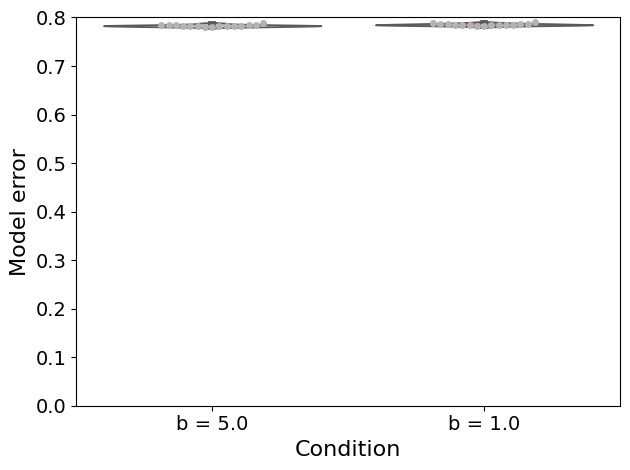

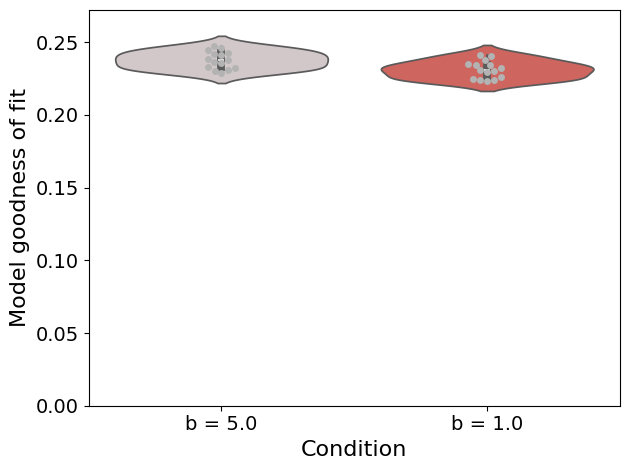

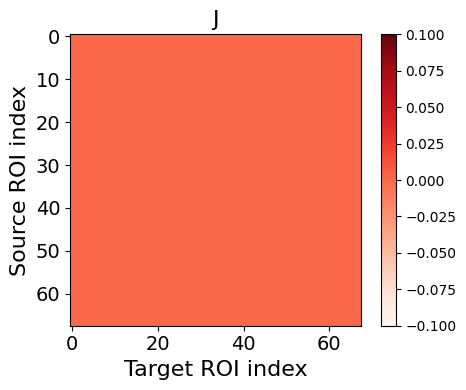

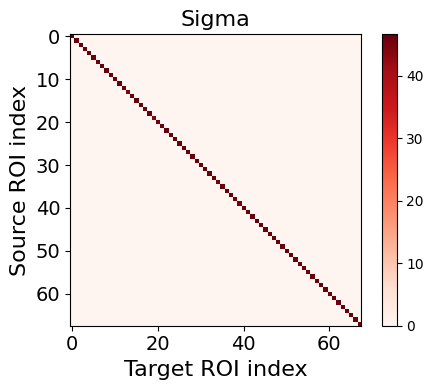

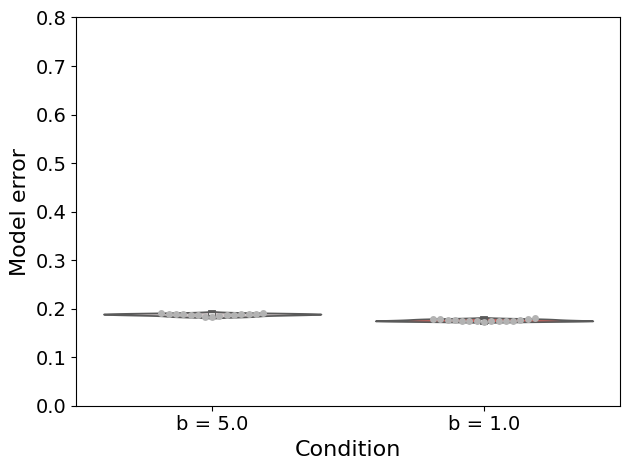

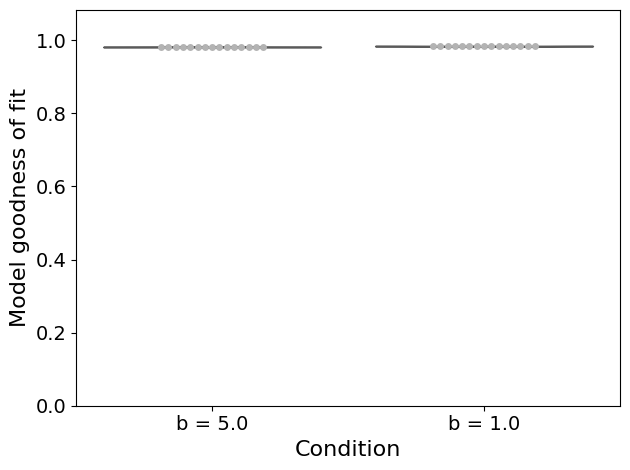

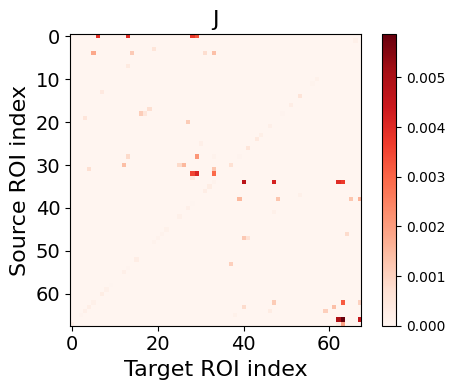

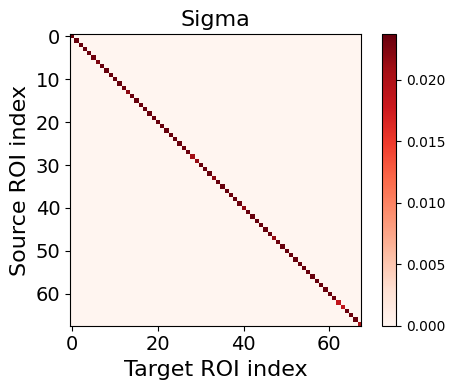

In [17]:
mask_diag = np.eye(n_regions, dtype=bool) # mask for diagonal elements

palette = {conds[0]: '#D4C6C9', conds[1]: '#E1544C'}

for situation_idx in range(len(situations)):
    res_dir_situation = os.path.join(res_dir, situations[situation_idx])
    print(f"Saving results for situation: {situations[situation_idx]} in directory: {res_dir}")
    err_mod = np.load(os.path.join(res_dir_situation, 'err_mod.npy'))
    print("err_mod shape:", err_mod.shape)
    fit_mod = np.load(os.path.join(res_dir_situation, 'fit_mod.npy'))
    print("fit_mod shape:", fit_mod.shape)
    J_mod = np.load(os.path.join(res_dir_situation, 'J_mod.npy'))
    print("J_mod shape:", J_mod.shape)
    Sigma_mod = np.load(os.path.join(res_dir_situation, 'Sigma_mod.npy'))
    print("Sigma_mod shape:", Sigma_mod.shape)

    # Model error
    plot_mod_diag(array_mod=err_mod, n_sub=n_sub, n_cond=n_cond, 
                   conds=conds, cols=palette, y_min=0, y_max = 0.8, 
                   plot_ylabel='Model error', 
                   file_name=f"model_fit_error.{graph_format}", 
                   graph_format=graph_format, res_dir=res_dir_situation)

    # Pearson correlation
    plot_mod_diag(array_mod=fit_mod, n_sub=n_sub, n_cond=n_cond, 
                   conds=conds, cols=palette, y_min=0, y_max = None, 
                   plot_ylabel='Model goodness of fit', 
                   file_name=f"model_goodness_fit.{graph_format}", 
                   graph_format=graph_format, res_dir=res_dir_situation)
    
    # J matrix 
    plot_mod_matrix(mod_matrix=J_mod, mod_matrix_name="J", res_dir=res_dir_situation, 
                    graph_format=graph_format)
    
    # Sigma matrix
    plot_mod_matrix(mod_matrix=Sigma_mod, mod_matrix_name="Sigma", res_dir=res_dir_situation, 
                    graph_format=graph_format)

### Compute Entropy Production Rate (EPR) $\Phi$ and plot results

should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0
should be close to zero: 0.0


c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\angelica_scripts\utils.py:620: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=data,


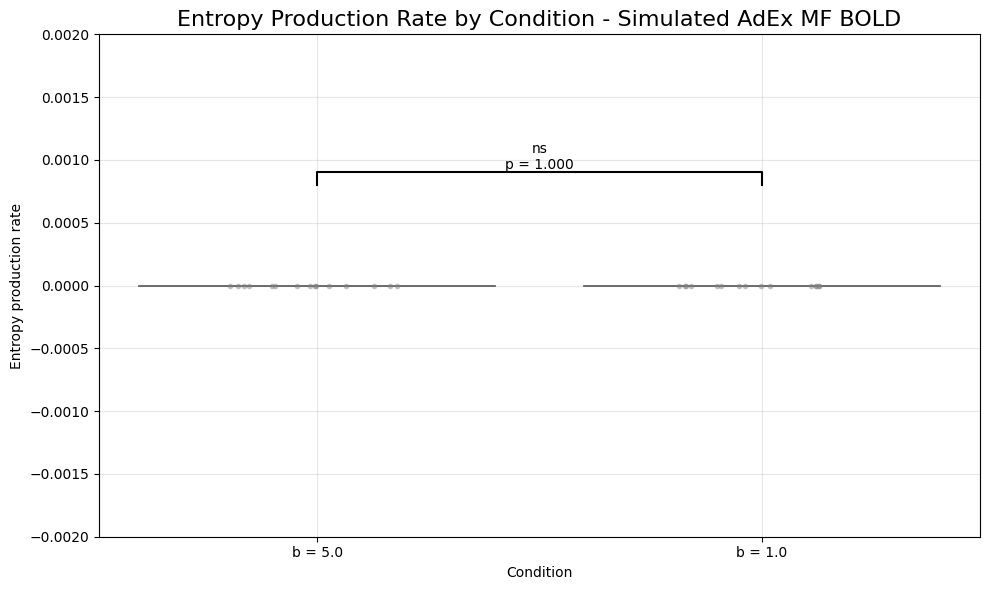


Statistical Test Results:
Mann-Whitney U test statistic: 112.5
p-value: 1.0
should be close to zero: 1.0061396160665481e-16
should be close to zero: 5.898059818321144e-17
should be close to zero: 5.551115123125783e-17
should be close to zero: 1.0408340855860843e-16
should be close to zero: 8.673617379884035e-17
should be close to zero: 9.71445146547012e-17
should be close to zero: 1.3530843112619095e-16
should be close to zero: 1.3877787807814457e-16
should be close to zero: 7.979727989493313e-17
should be close to zero: 3.469446951953614e-17
should be close to zero: 4.5102810375396984e-17
should be close to zero: 1.0408340855860843e-17
should be close to zero: 1.491862189340054e-16
should be close to zero: 8.673617379884035e-17
should be close to zero: 8.673617379884035e-17
should be close to zero: 9.71445146547012e-17
should be close to zero: 8.326672684688674e-17
should be close to zero: 4.85722573273506e-17
should be close to zero: 3.469446951953614e-17
should be close to zero: 8.

c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\angelica_scripts\utils.py:620: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=data,


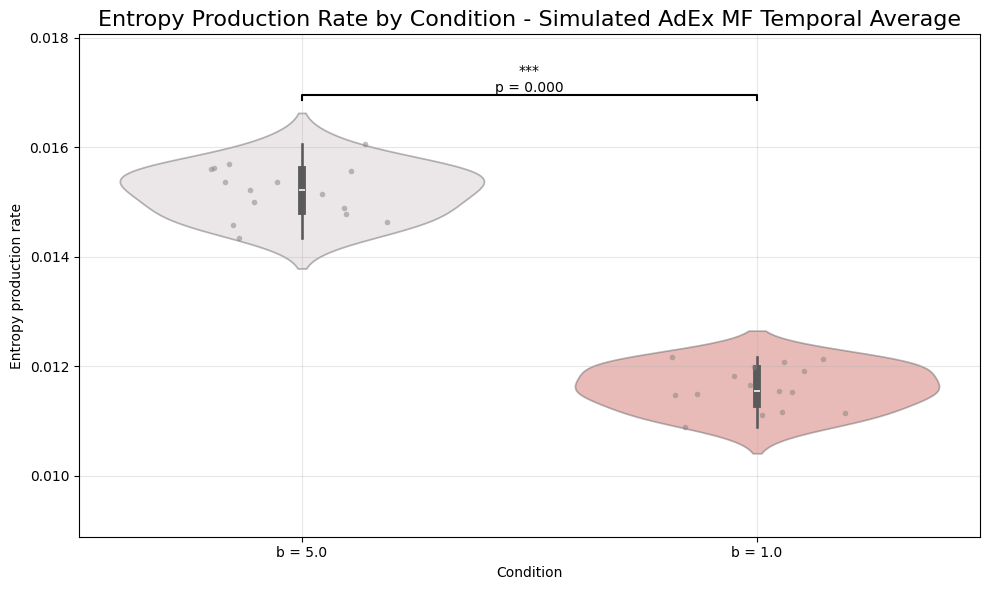


Statistical Test Results:
Mann-Whitney U test statistic: 225.0
p-value: 3.391821390825095e-06


In [18]:
mask_diag = np.eye(n_regions, dtype=bool) # mask for diagonal elements

cols = [[0.3,0.3,1],[0.2,0.2,0.8],[0.1,0.1,0.6],[0,0,0.4]] # colors

situations_title_dict = { 'simulated_adex_BOLD': 'Simulated AdEx MF BOLD', 'simulated_adex_FR': 'Simulated AdEx MF Temporal Average' }

for situation_idx in range(len(situations)):
    res_dir_situation = os.path.join(res_dir, situations[situation_idx])
    
    # Load matrices necessary to compute EPR
    J_mod = np.load(os.path.join(res_dir_situation, 'J_mod.npy'))
    Sigma_mod = np.load(os.path.join(res_dir_situation, 'Sigma_mod.npy'))
    FC0_mod = np.load(os.path.join(res_dir_situation, 'FC0_mod.npy'))

    ## Compute EPR
    EPR = np.zeros([n_sub,n_cond])
    Q_indiv = np.zeros([n_sub,n_cond,n_regions,n_regions])

    for i_sub in range(n_sub):
        for i_cond in range(n_cond):

            try:
                B = np.copy(-J_mod[i_sub,i_cond,:,:].T) # B=-J
                D = np.copy(0.5 * Sigma_mod[i_sub,i_cond,:,:]) # D=1/2 * Sigma
                S = np.copy(FC0_mod[i_sub,i_cond,:,:])
                
                Q = np.dot(B, S) - D
                Q_indiv[i_sub,i_cond,:,:] = Q
                
                # sanity check
                if True:
                    print('should be close to zero:', np.abs(np.dot(B,S) + np.dot(S,B.T) -2*D).max())
                
                # formula from Godreche Luck
                Dinv = np.linalg.pinv(D)
                Sinv = np.linalg.pinv(S)
                
                entropy_prod_rate = -np.trace(np.dot(np.dot(np.dot(Sinv, Q), Dinv), Q))  #-tr(S^(-1)*Q*D^(-1)*Q)
                EPR[i_sub,i_cond] = entropy_prod_rate

            except:
                print('problem with subject/cond:', i_sub, i_cond)
        

    np.save(os.path.join(res_dir_situation,'EPR.npy'),EPR)

    ## Plot results
    # Turn into dataframe for plotting
    EPR_tmp = dict()
    EPR_tmp['sleep stage'] = np.repeat(np.array(conds, dtype=str).reshape([-1,n_cond]), n_sub, axis=0).flatten()
    EPR_tmp['EPR'] = EPR.flatten()

    EPR_df = pd.DataFrame(EPR_tmp)

    #EPR_df=EPR_df.drop(index=13)

    # Create sample data (replace with your actual data)
    data = pd.DataFrame({
        'Condition': [conds[0]]*nb_seeds + [conds[1]]*nb_seeds,
        'Entropy_production_rate': np.concatenate([
            EPR_df[EPR_df['sleep stage'] == conds[0]]['EPR'].tolist(),
            EPR_df[EPR_df['sleep stage'] == conds[1]]['EPR'].tolist()
        ])
    })

    # Perform statistical test
    ctr_data = data[data['Condition'] == conds[0]]['Entropy_production_rate']
    scz_data = data[data['Condition'] == conds[1]]['Entropy_production_rate']

    # Perform Mann-Whitney U test (non-parametric test for independent samples)
    statistic, p_value = stats.mannwhitneyu(ctr_data, scz_data, alternative='two-sided')

    # Plot EPR for all conditions and save in results directory
    plot_entropy_prod_rate(data, situations, situation_idx, situations_title_dict, res_dir_situation, graph_format, conds, p_value)

    # Print statistical test results
    print(f'\nStatistical Test Results:')
    print(f'Mann-Whitney U test statistic: {statistic}')
    print(f'p-value: {p_value}')
    # Save results as a csv file
    stat_results_df = pd.DataFrame({
        'Mann-Whitney U test statistic': [statistic],
        'p-value': [p_value]
    })
    stat_results_df.to_csv(os.path.join(res_dir_situation,"stat_test_results.csv"), index=False)

        